# **Proyecto BMW**

**Data Engineering**

In [1]:
pip show pandas numpy scikit-learn scipy matplotlib seaborn | grep -E "^(Name|Version)"

Name: pandas
Version: 2.3.3
Name: numpy
Version: 2.3.4
Name: scikit-learn
Version: 1.7.2
Name: scipy
Version: 1.16.3
Name: matplotlib
Version: 3.10.7
Name: seaborn
Version: 0.13.2
Note: you may need to restart the kernel to use updated packages.


In [ ]:
# Este es el primer entregable que tenéis que realizar. En el Campus está el fichero con los datos que contiene datos de coches de BMW.
#El objetivo es que realicéis la limpieza y el preprocesado de los datos con la finalidad de crear un modelo que pueda predecir el precio
# (¡ojo! no hay que hacer la predicción, pero es el objetivo a tener en cuenta).

In [ ]:
# Os adjunto el formulario en el que están todas las preguntas y que tendréis que rellenar y mandar cuando acabéis:,
# https://docs.google.com/forms/d/e/1FAIpQLSfm1X41heoei-hnUWnfBucTPHQbt11txtqFFLljqF0s042kKg/viewform

In [1]:
!pip install pandas numpy scikit-learn matplotlib seaborn jinja2 sklearn.preprocessing importlib

In [2]:
import pandas as pd # Librería para la manipulación y el análisis de datos
import numpy as np # Librería para la manipulación de datos y para la ejecución de operaciones matemáticas
import matplotlib.pyplot as plt # Librería para la visualización de datos
import seaborn as sns # Librería para la visualización de datos
from sklearn.preprocessing import LabelEncoder, MinMaxScaler, OrdinalEncoder, OneHotEncoder # Librería para crear modelos de ML
import sys
import os
import importlib

# Obtiene la ruta absoluta del directorio actual del script
# current_dir = os.path.dirname(os.path.abspath(__file__))  # python
current_dir = os.getcwd()                                   # jupyter notebook

# Obtiene la ruta al directorio 'src' (subiendo un nivel y entrando a src)
src_path = os.path.join(current_dir, '..', 'src')

# Lo añade al path de Python, colocando src_path al principio para priorizarlo
sys.path.insert(0, src_path)

# Ahora ya puedes importar
import utils
importlib.reload(utils)  # Forzar recarga si ya se había importado antes

<module 'utils' from '/usr/local/lib/python3.12/dist-packages/utils/__init__.py'>

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [8]:
import os

# List contents of MyDrive to help locate the file
print(os.listdir('/content/drive/My Drive'))

['bmw.ipynb', 'parrilla de valoración teatro 1 B.doc (recuperado) (1).gdoc', 'parrilla de valoración teatro 1 B.doc (recuperado).gdoc', 'CHRISTIAN MÉNDEZ GIRALDO.gdoc', 'Encuesta nutricional personalizada - @Cliukdeel97 (respuestas).gsheet', '2017-18-F2_Méndez_Giraldo_Christian - Line chart 1.gsheet', 'Valoració rendes_plantilla_def (2).gsheet', 'Valoració rendes_plantilla_def (1).gsheet', 'Valoració rendes_plantilla_def.gsheet', 'Empréstits Entregar (1).gsheet', 'Empréstits Entregar.gsheet', 'TÒPIC 1_GENDER_Sessio 3.gdoc', 'marc projectes 3 eco 1.gdoc', 'Third Party Authorization Letter _BDSwiss BDS Markets MAU_.gdoc', 'Ejercicio Contabilidad.gsheet', 'Examen Microeconomia.gdoc', 'Casos Finales.gdoc', 'Documento de Google Keep.gdoc', 'Documento sin título (3).gdoc', 'Documento sin título (2).gdoc', 'CAUSAS Y CONSECUENCIAS ESTADO ACTUAL Y FUTURO DE LAS PENSIONES.gdoc', 'Documento sin título (1).gdoc', 'Malo_Molina_2003_Una_vision_macroeconomica_de_los_25_anos_de_la_Constit

In [11]:
import os

# List contents of MyDrive to help locate the file
print(os.listdir('/content/drive/My Drive'))

['bmw.ipynb', 'parrilla de valoración teatro 1 B.doc (recuperado) (1).gdoc', 'parrilla de valoración teatro 1 B.doc (recuperado).gdoc', 'CHRISTIAN MÉNDEZ GIRALDO.gdoc', 'Encuesta nutricional personalizada - @Cliukdeel97 (respuestas).gsheet', '2017-18-F2_Méndez_Giraldo_Christian - Line chart 1.gsheet', 'Valoració rendes_plantilla_def (2).gsheet', 'Valoració rendes_plantilla_def (1).gsheet', 'Valoració rendes_plantilla_def.gsheet', 'Empréstits Entregar (1).gsheet', 'Empréstits Entregar.gsheet', 'TÒPIC 1_GENDER_Sessio 3.gdoc', 'marc projectes 3 eco 1.gdoc', 'Third Party Authorization Letter _BDSwiss BDS Markets MAU_.gdoc', 'Ejercicio Contabilidad.gsheet', 'Examen Microeconomia.gdoc', 'Casos Finales.gdoc', 'Documento de Google Keep.gdoc', 'Documento sin título (3).gdoc', 'Documento sin título (2).gdoc', 'CAUSAS Y CONSECUENCIAS ESTADO ACTUAL Y FUTURO DE LAS PENSIONES.gdoc', 'Documento sin título (1).gdoc', 'Malo_Molina_2003_Una_vision_macroeconomica_de_los_25_anos_de_la_Constit

In [ ]:
df_inicial = pd.read_csv("/content/drive/My Drive/bmw_pricing_v3.csv")

In [12]:
df_inicial = pd.read_csv("/content/drive/My Drive/bmw_pricing_v3.csv")

In [13]:
print("Shape:", df_inicial.shape) #Hacemos head para ver las 5 primeras columnas empezando por el 0.
df_inicial.head()

Shape: (4843, 18)


,marca,modelo,km,potencia,fecha_registro,tipo_gasolina,color,tipo_coche,volante_regulable,aire_acondicionado,camara_trasera,asientos_traseros_plegables,elevalunas_electrico,bluetooth,gps,alerta_lim_velocidad,precio,fecha_venta
0,NaN,118,140411.0,100.0,2012-02-01,diesel,black,NaN,True,True,False,NaN,True,NaN,True,NaN,11300.0,2018-01-01
1,BMW,M4,13929.0,317.0,NaN,petrol,grey,convertible,True,True,False,NaN,False,True,True,True,69700.0,2018-02-01
2,BMW,320,183297.0,120.0,2012-04-01,diesel,white,NaN,False,False,False,NaN,True,False,True,False,10200.0,2018-02-01
3,BMW,420,128035.0,135.0,NaN,diesel,red,convertible,True,True,False,NaN,True,True,True,NaN,25100.0,2018-02-01
4,BMW,425,97097.0,160.0,NaN,diesel,silver,NaN,True,True,False,False,False,True,True,True,33400.0,2018-04-01


In [14]:
df_inicial.info()  # Hacemos info, para ver el tipo de dato de cada columna

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4843 entries, 0 to 4842
Data columns (total 18 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   marca                        3873 non-null   object 
 1   modelo                       4840 non-null   object 
 2   km                           4841 non-null   float64
 3   potencia                     4842 non-null   float64
 4   fecha_registro               2420 non-null   object 
 5   tipo_gasolina                4838 non-null   object 
 6   color                        4398 non-null   object 
 7   tipo_coche                   3383 non-null   object 
 8   volante_regulable            4839 non-null   object 
 9   aire_acondicionado           4357 non-null   object 
 10  camara_trasera               4841 non-null   object 
 11  asientos_traseros_plegables  1452 non-null   object 
 12  elevalunas_electrico         4841 non-null   object 
 13  bluetooth         

In [15]:
df_inicial.isnull().sum() # Miramos el número de nulos que hay en cada columna.

,0
marca,970
modelo,3
km,2
potencia,1
fecha_registro,2423
tipo_gasolina,5
color,445
tipo_coche,1460
volante_regulable,4
aire_acondicionado,486


In [16]:
df_inicial.isnull().any()

,0
marca,True
modelo,True
km,True
potencia,True
fecha_registro,True
tipo_gasolina,True
color,True
tipo_coche,True
volante_regulable,True
aire_acondicionado,True


In [17]:
# Conversión con pd.to_datetime de los atributos que tienen fecha y son float
df_inicial_test = df_inicial.copy()
for i in df_inicial.columns:
    if str(i).upper().startswith('FECHA'):
        df_inicial_test[i] = pd.to_datetime(df_inicial[i])

df_inicial_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4843 entries, 0 to 4842
Data columns (total 18 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   marca                        3873 non-null   object        
 1   modelo                       4840 non-null   object        
 2   km                           4841 non-null   float64       
 3   potencia                     4842 non-null   float64       
 4   fecha_registro               2420 non-null   datetime64[ns]
 5   tipo_gasolina                4838 non-null   object        
 6   color                        4398 non-null   object        
 7   tipo_coche                   3383 non-null   object        
 8   volante_regulable            4839 non-null   object        
 9   aire_acondicionado           4357 non-null   object        
 10  camara_trasera               4841 non-null   object        
 11  asientos_traseros_plegables  1452 non-null 

In [18]:
df_inicial_test[df_inicial_test.duplicated(keep='first')].shape

(0, 18)

---

In [19]:
for i in df_inicial_test.columns:
    prctj = df_inicial_test[i].isnull().mean() * 100
    print(f'{prctj:.2f}% \tde nulos en {i}')

20.03% 	de nulos en marca
0.06% 	de nulos en modelo
0.04% 	de nulos en km
0.02% 	de nulos en potencia
50.03% 	de nulos en fecha_registro
0.10% 	de nulos en tipo_gasolina
9.19% 	de nulos en color
30.15% 	de nulos en tipo_coche
0.08% 	de nulos en volante_regulable
10.04% 	de nulos en aire_acondicionado
0.04% 	de nulos en camara_trasera
70.02% 	de nulos en asientos_traseros_plegables
0.04% 	de nulos en elevalunas_electrico
15.03% 	de nulos en bluetooth
0.00% 	de nulos en gps
15.03% 	de nulos en alerta_lim_velocidad
0.12% 	de nulos en precio
0.02% 	de nulos en fecha_venta


In [20]:
for i in df_inicial.columns: # Loop en las columnas del DataF
    print('\n',i,df_inicial[i].unique(),'\n\n')


 marca [nan 'BMW'] 



 modelo ['118' 'M4' '320' '420' '425' '335' '325' 'Z4' '120' '220' '650' '135'
 '218' '318' '430' 'M3' '330' '225' 'M235' '316' '435' '640'
 '640 Gran Coupé' '435 Gran Coupé' 'i8' '630' '430 Gran Coupé' '635' '520'
 nan '525' '530' '535' '320 Gran Turismo' '518' '116' '328' '523' 'X3'
 'M550' '528' '325 Gran Turismo' '125' '318 Gran Turismo' '420 Gran Coupé'
 'i3' '114' '520 Gran Turismo' '530 Gran Turismo' 'M135' '418 Gran Coupé'
 '330 Gran Turismo' '335 Gran Turismo' '730' '123' '535 Gran Turismo'
 '740' '750' 'ActiveHybrid 5' '735' 'M5' 'X5' 'X1' 'X4' 'X6' 'X6 M' 'X5 M'
 'X5 M50' '218 Active Tourer' '218 Gran Tourer' '216' '220 Active Tourer'
 '216 Gran Tourer' '216 Active Tourer' ' Active Tourer'
 '225 Active Tourer' '214 Gran Tourer'] 



 km [140411.  13929. 183297. ...  19633.  27920. 195840.] 



 potencia [100. 317. 120. 135. 160. 225. 145. 105. 125. 130. 270. 110. 140. 180.
  85. 190. 236. 240. 250. 230. 309. 170. 142. 155. 210.  nan 122. 200.
  90. 15

<Axes: >

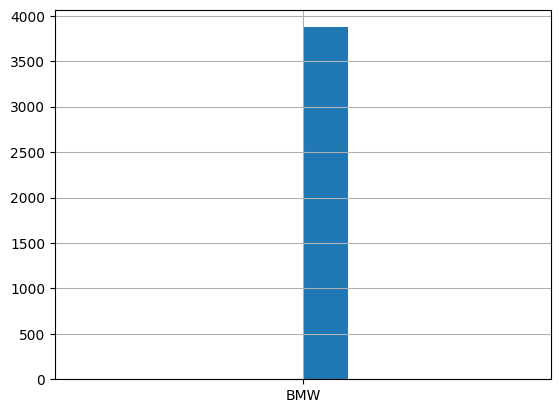

In [39]:
df_inicial["marca"].hist() # Hacemos un Hist de marca para ver valores unicos agrupados,
# vemos que no existe otra marca. todo el documento es de la marca BMW por lo que es una columnaque no aporta valor al modelo

In [21]:
df_inicial[df_inicial.duplicated(keep=False)] ## miramos cuantos duplicados tenemos. No se aprecian observaciones duplicadas.

,marca,modelo,km,potencia,fecha_registro,tipo_gasolina,color,tipo_coche,volante_regulable,aire_acondicionado,camara_trasera,asientos_traseros_plegables,elevalunas_electrico,bluetooth,gps,alerta_lim_velocidad,precio,fecha_venta


# Ejercicio 1

### ¿Qué columnas eliminaron inicialmente del dataset y por qué?

In [22]:
df_inicial_test_2 = df_inicial_test.copy()

# Borramos nulos en precio porque es el target principal
df_inicial_test_2 = df_inicial_test_2.dropna(subset=['precio'])
# Borramos columnas que no aportan valor
df_inicial_test_2 = df_inicial_test_2.drop(columns=['marca','asientos_traseros_plegables'])

# ELIMINAR COLUMNAS: Marca + Asientos_traseros_plegables
# Marca: Es eliminado porque todo el DataSet pertenecen a la marca de BMW,
# Asientos_traseros_plegables: El 75% de las observaciones son valores nulos y no son suficientes para el modelo,
# Nos quedamos con 16 columnas.

In [23]:
df_inicial_test.shape

(4843, 18)

In [24]:
df_inicial_test_2.shape

(4837, 16)

In [25]:
df_inicial_test_2["modelo"].value_counts() # Vemos la proporcion de modelos.

,count
modelo,
320,750
520,632
318,567
X3,438
116,358
...,...
216,1
220 Active Tourer,1
Active Tourer,1


In [26]:
df_inicial_test_2[df_inicial_test_2["modelo"].isnull()] # Miramos para la columna de Modelo, todos los registros en null. son tres registros.

,modelo,km,potencia,fecha_registro,tipo_gasolina,color,tipo_coche,volante_regulable,aire_acondicionado,camara_trasera,elevalunas_electrico,bluetooth,gps,alerta_lim_velocidad,precio,fecha_venta
173,NaN,146338.0,105.0,NaT,diesel,black,NaN,False,True,False,False,NaN,True,NaN,13300.0,2018-08-01
4766,NaN,115566.0,105.0,2014-01-01,diesel,silver,suv,False,True,False,True,False,True,False,14900.0,2018-09-01
4802,NaN,118640.0,110.0,NaT,diesel,white,NaN,False,False,False,False,False,False,False,800.0,2018-03-01


In [27]:
print((df_inicial_test_2.isnull().sum() / len(df_inicial_test_2)) * 100) # Miramos la canitdad % nulos en cada columna.

modelo                   0.062022
km                       0.041348
potencia                 0.020674
fecha_registro          49.989663
tipo_gasolina            0.103370
color                    9.179243
tipo_coche              30.142650
volante_regulable        0.082696
aire_acondicionado      10.026876
camara_trasera           0.041348
elevalunas_electrico     0.041348
bluetooth               15.050651
gps                      0.000000
alerta_lim_velocidad    15.050651
precio                   0.000000
fecha_venta              0.020674
dtype: float64


---

In [28]:
from sklearn.preprocessing import LabelEncoder
import pandas as pd # Librería para la manipulación y el análisis de datos
import numpy as np # Librería para la manipulación de datos y para la ejecución de operaciones matemáticas
import matplotlib.pyplot as plt # Librería para la visualización de datos
import seaborn as sns # Librería para la visualización de datosr, MinMaxScaler, OrdinalEncoder # Librería para crear modelos de ML

In [29]:
def columnas_por_tipo(df, as_dict=False):
    """
    Agrupa las columnas de un DataFrame por tipo y devuelve las listas de nombres de columnas.

    Parámetros:
    - df: pandas.DataFrame
    - as_dict: bool (opcional). Si True devuelve un dict con las listas;
               si False (por defecto) devuelve una tupla con las listas en el
               siguiente orden: (numeric, bools, datetimes, objects, categories,
               timedeltas, complex_cols, ints, floats, others).

    Retorno:
    - Si as_dict=True: dict con claves 'all','numeric','int','float','bool',
      'datetime','object','category','timedelta','complex','others'.
    - Si as_dict=False: tupla de listas: (numeric, bools, datetimes, objects,
      categories, timedeltas, complex_cols, ints, floats, grouped['others']).

    Ejemplos:
    - numeric, bools, datetimes, objects, categories, timedeltas, complex_cols,
      ints, floats, others = columnas_por_tipo(df)
    - grouped = columnas_por_tipo(df, as_dict=True)
    - df[numeric].head()  # muestra solo columnas numéricas si 'numeric' es la lista
    """
    # columnas por tipos básicos
    numeric = df.select_dtypes(include=['number']).columns.tolist()
    bools = df.select_dtypes(include=['bool']).columns.tolist()
    datetimes = df.select_dtypes(include=['datetime']).columns.tolist()
    objects = df.select_dtypes(include=['object']).columns.tolist()
    categories = df.select_dtypes(include=['category']).columns.tolist()
    timedeltas = df.select_dtypes(include=['timedelta']).columns.tolist()
    complex_cols = df.select_dtypes(include=['complex']).columns.tolist()

    # distinguir int / float dentro de numeric
    ints = [c for c in numeric if pd.api.types.is_integer_dtype(df[c])]
    floats = [c for c in numeric if pd.api.types.is_float_dtype(df[c])]

    grouped = {
        'all': df.columns.tolist(),
        'numeric': numeric,
        'int': ints,
        'float': floats,
        'bool': bools,
        'datetime': datetimes,
        'object': objects,
        'category': categories,
        'timedelta': timedeltas,
        'complex': complex_cols,
    }

    # columnas que no encajan en los grupos anteriores
    grouped_lists = [grouped[k] for k in ['numeric','int','float','bool','datetime','object','category','timedelta','complex']]
    used = set().union(*map(set, grouped_lists)) if grouped_lists else set()
    grouped['others'] = [c for c in df.columns if c not in used]

    if as_dict:
        return grouped

    # devolver las listas en un orden fijo para permitir unpacking directo
    return (numeric, bools, datetimes, objects, categories, timedeltas,
            complex_cols, ints, floats, grouped['others'])

In [30]:
def porcentaje_nulos(df):
    """
    Calcula el porcentaje de valores nulos en cada columna de un DataFrame.

    Parámetros:
    - df: pandas.DataFrame

    Retorno:
    - pandas.Series con el porcentaje de nulos por columna.
    """
    for i in df.columns:
        prctj = df[i].isnull().mean() * 100
        print(f'{prctj:.3f}% \tde nulos en {i}')
    return

In [31]:
def auditoria_nulos(df):
    """
    Realiza una auditoría de los valores nulos en un DataFrame.
    Parámetros:
    - df: pandas.DataFrame
    Retorno:
    - pandas.DataFrame con las filas que contienen al menos un valor nulo,
      incluyendo una columna adicional 'n_nulos' que indica el número de
      valores nulos en cada fila.
    """
    print("Auditoría de nulos en el DataFrame:")

    nulos_por_col = df.isnull().sum()
    cols_con_nulos = nulos_por_col[nulos_por_col > 0]

    if cols_con_nulos.empty:
        print("No hay nulos en este DataFrame.")
        return

    print(f"Columnas afectadas:\n{cols_con_nulos.sort_values(ascending=False)}")

    # Creamos una máscara para ver solo las filas que tienen AL MENOS un nulo
    filas_nulas = df[df.isnull().any(axis=1)].copy()

    # ¿Falta solo un dato o faltan 5 a la vez?
    filas_nulas['n_nulos'] = filas_nulas.isnull().sum(axis=1)

    print(f"\nTotal de filas con algún dato faltante: {len(filas_nulas)} ({len(filas_nulas)/len(df)*100:.2f}% del total)")
    print("\nDistribución de gravedad (¿Cuántos datos faltan por fila?):")
    display(filas_nulas['n_nulos'].value_counts().sort_index())

    print("\nEjemplo de filas con múltiples nulos (Top 5):")
    display(filas_nulas.sort_values('n_nulos', ascending=False).head(5))

    return filas_nulas

In [32]:
def auditoria_agrupada(df, columna_objetivo, columnas_agrupacion, ordenar_por_volumen=True):
    """
    Analiza la distribución de nulos agrupando por columnas.

    Parámetros:
    - df: DataFrame.
    - columna_objetivo: Columna a auditar (nulos).
    - columnas_agrupacion: Lista de columnas para agrupar.
    - ordenar_por_volumen:
        True -> Ordena por 'total_filas' descendente (Rompe grupos para mostrar lo más grande primero).
        False -> Ordena jerárquicamente por 'columnas_agrupacion' (Mantiene el orden lógico del índice).
    """
    print(f"📊 Analizando '{columna_objetivo}' agrupado por {columnas_agrupacion}...")

    # Agrupamos (dropna=False para ver nulos en la agrupación)
    resumen = df.groupby(columnas_agrupacion, dropna=False).agg(
        total_filas=(columna_objetivo, 'size'),
        nulos_objetivo=(columna_objetivo, lambda x: x.isnull().sum())
    )

    # Métricas
    resumen['pct_nulos'] = (resumen['nulos_objetivo'] / resumen['total_filas'] * 100).round(2)
    resumen['peso_grupo_%'] = (resumen['total_filas'] / len(df) * 100).round(2)

    # Lógica de Ordenamiento
    if ordenar_por_volumen:
        # Prioriza el volumen total (Rompe la jerarquía visual de regiones)
        return resumen.sort_values('total_filas', ascending=False)
    else:
        # Prioriza la jerarquía de las columnas de agrupación
        # Además, dentro de cada grupo, ordenamos por volumen descendente para que quede bonito
        return resumen.sort_values(columnas_agrupacion + ['total_filas'], ascending=[True]*len(columnas_agrupacion) + [False])

In [33]:
def agrupador(df, columna, valores_a_mantener, group_as="Other_countries"):
    """
    Agrupa los valores de una columna que NO estén en la lista 'valores_a_mantener'
    bajo una nueva etiqueta.

    Mejoras:
    - Admite tanto lista ['A', 'B'] como string único 'A'.
    - Retorna una copia para no dañar el dataset original.
    - Imprime resumen del cambio.
    """
    # 1. Protección: Si el usuario pasa un string suelto, lo convertimos a lista
    if isinstance(valores_a_mantener, str):
        valores_a_mantener = [valores_a_mantener]

    print(f"\n   Procesando columna '{columna}'...")
    print(f"   Manteniendo intactos: {valores_a_mantener}")
    print(f"   Agrupando el resto en: '{group_as}'")

    # 2. Seguridad: Trabajamos sobre una copia
    df_out = df.copy()

    # 3. Lógica de Agrupación (Vectorizada)
    # Seleccionamos todo lo que NO (~) esté en la lista blanca
    mask = ~df_out[columna].isin(valores_a_mantener)
    num_afectados = mask.sum()

    # Aplicamos el cambio
    df_out.loc[mask, columna] = group_as

    # 4. Reporte final
    print(f"   ¡Hecho! Se han agrupado {num_afectados} filas.")
    print(f"   Distribución final:\n{df_out[columna].value_counts().head()}")

    return df_out

In [34]:
def visualizar_correlacion(df, col_x, col_y, hue=None, tipo_grafico='auto'):
    """
    Visualiza la relación entre dos variables eligiendo el gráfico adecuado.

    Parámetros:
    - df: DataFrame.
    - col_x: Variable eje X.
    - col_y: Variable eje Y.
    - hue: (Opcional) Variable para segmentar por colores (ej. 'active_customer').
    - tipo_grafico: 'auto', 'scatter', 'box', 'heatmap', 'bar'.
    """

    # Preparar lienzo
    plt.figure(figsize=(10, 6))

    # Detectar tipos de datos
    es_numerica_x = pd.api.types.is_numeric_dtype(df[col_x])
    es_numerica_y = pd.api.types.is_numeric_dtype(df[col_y])

    # Lógica de decisión automática
    if tipo_grafico == 'auto':
        if es_numerica_x and es_numerica_y:
            tipo_grafico = 'scatter' # Num vs Num (ej. Edad vs Salario)
            # Si hay demasiados puntos (>10k), mejor un hexbin o samplear
            if len(df) > 10000: tipo_grafico = 'hexbin'

        elif (not es_numerica_x) and es_numerica_y:
            tipo_grafico = 'box' # Cat vs Num (ej. Segmento vs Salario)

        elif es_numerica_x and (not es_numerica_y):
            # Intercambiamos ejes para que la categoría quede en X (mejor lectura)
            col_x, col_y = col_y, col_x
            tipo_grafico = 'box'

        else:
            tipo_grafico = 'heatmap' # Cat vs Cat (ej. Región vs Segmento)

    print(f" Generando gráfico tipo: {tipo_grafico.upper()} para {col_x} vs {col_y}")

    # --- GENERACIÓN DE GRÁFICOS ---

    if tipo_grafico == 'scatter':
        sns.scatterplot(data=df, x=col_x, y=col_y, hue=hue, alpha=0.6)
        plt.title(f"Correlación: {col_x} vs {col_y}")

    elif tipo_grafico == 'hexbin':
        # Hexbin es mejor para millones de datos que Scatter
        plt.hexbin(df[col_x], df[col_y], gridsize=50, cmap='Blues')
        plt.colorbar(label='Cantidad de Clientes')
        plt.xlabel(col_x)
        plt.ylabel(col_y)
        plt.title(f"Densidad: {col_x} vs {col_y}")

    elif tipo_grafico == 'box':
        sns.boxplot(data=df, x=col_x, y=col_y, hue=hue)
        plt.title(f"Distribución de {col_y} por {col_x}")
        plt.xticks(rotation=45)

    elif tipo_grafico == 'heatmap':
        # Tabla de contingencia (Crosstab)
        ct = pd.crosstab(df[col_x], df[col_y], normalize='index') # % por fila
        sns.heatmap(ct, annot=True, cmap="YlGnBu", fmt=".2%")
        plt.title(f"Relación Categorica: {col_x} vs {col_y}")

    elif tipo_grafico == 'bar':
        # Útil para ver la media de una variable Y por cada categoría de X
        sns.barplot(data=df, x=col_x, y=col_y, hue=hue, errorbar=None)
        plt.title(f"Media de {col_y} por {col_x}")
        plt.xticks(rotation=45)

    plt.tight_layout()
    plt.show()

In [35]:
def analizar_correlaciones_productos(df, cols_productos, agrupar=False, clave_agrupar=None):
    """
    Genera un Mapa de Calor (Heatmap) para múltiples columnas booleanas en base a una agrupación.

    Parámetros:
    - df: DataFrame.
    - cols_productos: Lista de las columnas boleanas o binarias a relacionar.
    - agrupar:

        * False (Default): agrupa por el primer pk_ o columna que detecte

        * True: Analiza el perfil general (¿El cliente que contrata X suele contratar Y?)

    - clave_agrupar: (Opcional) Columna específica para agrupar. Si no se proporciona, se busca la primera columna 'pk_'.
    """

    # Preparamos los datos
    if agrupar:
        if clave_agrupar is None:
            for col in df.columns:
                if 'pk_' in col and col != 'pk_partition':
                    clave_agrupar = col
                    break
                else:
                    raise ValueError("No se encontró una columna 'pk_' para agrupar. Por favor, especifica 'clave_agrupar'.")

            df_analisis = df.groupby(clave_agrupar)[cols_productos].max()
        else:
            df_analisis = df.groupby(clave_agrupar)[cols_productos].max()
        print(f"Agrupando por {clave_agrupar}")
    else:
        df_analisis = df[cols_productos]

    # Cálculo de la Correlación
    # Para variables binarias (0/1), Pearson funciona como el coeficiente Phi
    corr_matrix = df_analisis.corr(method='pearson')

    # Diseño del Gráfico
    plt.figure(figsize=(14, 12))

    # Heatmap
    # cmap='RdBu_r': Rojo para inversa (si tengo X no tengo Y), Azul para directa (van juntos)
    sns.heatmap(
        corr_matrix,
        annot=True,     # Muestra el número
        fmt=".2f",      # 2 decimales
        cmap='RdBu',  # Escala de colores Rojo-Azul
        vmin=-0.2, vmax=0.6, # Ajustamos el rango para resaltar correlaciones sutiles (pocas pasan de 0.6)
        center=0,       # El blanco es correlación cero
        linewidths=0.5, # Líneas entre celdas
        cbar_kws={"shrink": .5} # Barra de leyenda más pequeña
    )

    plt.title(f"Correlación de booleanos por {clave_agrupar if agrupar else 'relación general'}", fontsize=16)
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.show()

In [36]:
def imputar_por_similitud(df, target_col, numeric_cols, cat_bool_cols, umbral_dominancia=0.75, margen_global=0.05, usar_percentiles=False, estrategia='moda'):
    """
        Imputa valores nulos en una columna objetivo basándose en la similitud con otros registros (vecinos).

        Esta función busca filas similares a aquellas que tienen datos faltantes en `target_col`.
        La similitud se define mediante coincidencias exactas en variables categóricas/booleanas
        y proximidad dentro de un margen en variables numéricas.

        Lógica de búsqueda de vecinos:
        1. Filtro estricto: Debe coincidir el valor en todas las columnas de `cat_bool_cols`.
        2. Filtro numérico: El valor debe estar dentro de un rango (margen) definido para `numeric_cols`.
        - Si `usar_percentiles=False`: Rango = valor ± (valor * margen).
        - Si `usar_percentiles=True`: Rango = percentiles correspondientes al (rank_actual ± margen).

        Args:
            df (pd.DataFrame): DataFrame original conteniendo los datos.
            target_col (str): Nombre de la columna que contiene los valores nulos a imputar.
            numeric_cols (list o dict):
                - Si es lista: Columnas numéricas para comparar similitud usando `margen_global`.
                - Si es dict: Claves son columnas y valores son el margen específico para esa columna (ej. {'edad': 0.1}).
            cat_bool_cols (list): Lista de columnas categóricas o booleanas para coincidencia exacta (Hard matching).
            umbral_dominancia (float, opcional): Solo para estrategia 'moda'. Porcentaje mínimo de coincidencia
                entre vecinos para aceptar la imputación (defecto 0.75).
            margen_global (float, opcional): Tolerancia por defecto para la comparación numérica (defecto 0.05 o 5%).
            usar_percentiles (bool, opcional): Define cómo se calcula el margen numérico.
                False usa distancia relativa al valor; True usa distancia en la distribución (quantiles).
            estrategia (str, opcional): Método de agregación de los vecinos encontrados.
                - 'moda': Valor más frecuente (requiere cumplir `umbral_dominancia`).
                - 'mediana': Mediana de los vecinos (soporta números y fechas).
                - 'media': Promedio aritmético (solo números).

        Returns:
            pd.DataFrame: Una copia del DataFrame original con los valores imputados donde fue posible.
    """

    df_out = df.copy()

    if df_out[target_col].isnull().sum() == 0:
        return df_out

    filas_nulas = df_out[df_out[target_col].isnull()]
    print(f"Procesando {len(filas_nulas)} nulos en '{target_col}' | Estrategia: {estrategia} | Percentiles: {usar_percentiles}...")

    imputaciones = 0

    # Pre-procesamiento config numérica
    if isinstance(numeric_cols, list):
        numeric_config = {col: margen_global for col in numeric_cols}
    else:
        numeric_config = numeric_cols

    for idx, row in filas_nulas.iterrows():
        mask = pd.Series([True] * len(df), index=df.index)

        # 1. Filtros
        for col in cat_bool_cols:
            valor = row[col]
            if not pd.isna(valor):
                mask &= (df[col] == valor)

        for col, margen_especifico in numeric_config.items():
            valor = row[col]
            if not pd.isna(valor):
                if usar_percentiles:
                    # Lógica Percentil
                    rank_actual = (df[col] < valor).mean()
                    q_min = max(0, rank_actual - margen_especifico)
                    q_max = min(1, rank_actual + margen_especifico)
                    try:
                        lim_inf = df[col].quantile(q_min)
                        lim_sup = df[col].quantile(q_max)
                        mask &= (df[col].between(lim_inf, lim_sup))
                    except: pass
                else:
                    # Lógica Rango Fijo
                    try:
                        lim_inf = valor * (1 - margen_especifico)
                        lim_sup = valor * (1 + margen_especifico)
                        if valor < 0: lim_inf, lim_sup = lim_sup, lim_inf
                        mask &= (df[col].between(lim_inf, lim_sup))
                    except: pass

        mask &= (df.index != idx)
        vecinos = df.loc[mask, target_col]

        vecinos = vecinos.dropna()

        if vecinos.empty:
            continue

        # 2. DECISIÓN SEGÚN ESTRATEGIA
        valor_imputado = None

        if estrategia == 'moda':
            # Lógica original: Requiere consenso
            conteo = vecinos.value_counts(normalize=True)
            if not conteo.empty:
                if conteo.iloc[0] >= umbral_dominancia:
                    valor_imputado = conteo.index[0]

        elif estrategia == 'mediana':
            # Lógica numérica/fechas: Valor central
            # Para fechas, convertimos a numérico, calculamos mediana y reconvertimos
            if pd.api.types.is_datetime64_any_dtype(vecinos):
                mediana_num = vecinos.astype(np.int64).median()
                valor_imputado = pd.to_datetime(mediana_num)
            else:
                valor_imputado = vecinos.median()

        elif estrategia == 'media':
             if pd.api.types.is_numeric_dtype(vecinos):
                valor_imputado = vecinos.mean()

        # 3. Asignación
        if valor_imputado is not None:
            df_out.at[idx, target_col] = valor_imputado
            imputaciones += 1

    print(f"Terminado: Se imputaron {imputaciones} de {len(filas_nulas)} ({round(imputaciones/len(filas_nulas)*100, 2)}%).")
    return df_out

In [37]:
def detectar_outliers_iqr(df, columnas_numericas):
    outliers_dict = {}
    for col in columnas_numericas:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1

        lim_inf = Q1 - 1.5 * IQR
        lim_sup = Q3 + 1.5 * IQR

        # Filtramos los valores que caen fuera
        mask_outliers = (df[col] < lim_inf) | (df[col] > lim_sup)
        n_outliers = mask_outliers.sum()

        if n_outliers > 0:
            outliers_dict[col] = {
                'n_outliers': n_outliers,
                'lim_inf': lim_inf,
                'lim_sup': lim_sup,
                '%_dataset': mask_outliers.mean() * 100
            }
            print(f"{col}: {n_outliers} outliers detectados ({outliers_dict[col]['%_dataset']:.2f}%)")

    return outliers_dict

In [38]:
from sklearn.base import BaseEstimator, TransformerMixin
import pandas as pd

class ScaledKNNImputer(BaseEstimator, TransformerMixin):
    def __init__(self, scaler=None, imputer=None):
        self.scaler = scaler if scaler else StandardScaler()
        self.imputer = imputer if imputer else KNNImputer(n_neighbors=5)

    def fit(self, X, y=None):
        # 1. Ajustamos el escalador con los datos disponibles
        self.scaler.fit(X)
        # 2. Transformamos para que el KNN aprenda sobre datos escalados
        X_scaled = self.scaler.transform(X)
        # 3. Ajustamos el KNN
        self.imputer.fit(X_scaled)
        return self

    def transform(self, X):
        # 1. Escalar
        X_scaled = self.scaler.transform(X)
        # 2. Imputar (devuelve datos escalados sin nulos)
        X_imputed_scaled = self.imputer.transform(X_scaled)
        # 3. Desescalar (volvemos a las unidades originales)
        X_imputed_original = self.scaler.inverse_transform(X_imputed_scaled)

        if isinstance(X, pd.DataFrame):
            return pd.DataFrame(
                X_imputed_original,
                columns=X.columns,
                index=X.index
            )
        return X_imputed_original

In [39]:
df_inicial_test_2.describe()

,km,potencia,fecha_registro,precio,fecha_venta
count,4.835000e+03,4836.000000,2419,4837.000000,4836
mean,1.409664e+05,128.995037,2012-12-06 04:18:56.998759936,15831.920612,2018-04-26 13:24:33.945409280
min,-6.400000e+01,0.000000,1990-03-01 00:00:00,100.000000,2007-08-01 00:00:00
25%,1.028700e+05,100.000000,2012-07-01 00:00:00,10800.000000,2018-03-01 00:00:00
50%,1.410680e+05,120.000000,2013-07-01 00:00:00,14200.000000,2018-05-01 00:00:00
75%,1.752435e+05,135.000000,2014-04-01 00:00:00,18600.000000,2018-07-01 00:00:00
max,1.000376e+06,423.000000,2017-11-01 00:00:00,178500.000000,2018-09-01 00:00:00
std,6.022079e+04,39.011169,NaN,9222.630708,NaN


Al hacer describe para las variables numéricas, surgen varios problemas:

· El mínimo de km es -64. Valor negativo no puede ser! El máx es kms es de 1.000.000 de kms. Es demasiado alto!

· La potencia mínima es 0, ¿Coche con 0 de potencia? Mientras que el máximo es de 423 (posible outlier)

· El máximo de precio es de 178.500. Es demasiado alto!

In [40]:
# Para ver valores más bajos - COLOCA UNA COLUMNA A LA VEZ
print("VALORES MÁS BAJOS DE KM:")
print(df_inicial_test_2['km'].nsmallest(5))

print("\nVALORES MÁS BAJOS DE POTENCIA:")
print(df_inicial_test_2['potencia'].nsmallest(5))

print("\nVALORES MÁS BAJOS DE PRECIO:")
print(df_inicial_test_2['precio'].nsmallest(5))

print("\nVALORES MÁS ALTOS DE KM:")
print(df_inicial_test_2['km'].nlargest(5))

print("\nVALORES MÁS ALTOS DE POTENCIA:")
print(df_inicial_test_2['potencia'].nlargest(5))

print("\nVALORES MÁS ALTOS DE PRECIO:")
print(df_inicial_test_2['precio'].nlargest(5))

VALORES MÁS BAJOS DE KM:
2938     -64.0
2409     476.0
4372     612.0
3935     706.0
3687    2399.0
Name: km, dtype: float64

VALORES MÁS BAJOS DE POTENCIA:
3765     0.0
1796    25.0
1925    25.0
2390    66.0
2771    66.0
Name: potencia, dtype: float64

VALORES MÁS BAJOS DE PRECIO:
565     100.0
630     100.0
879     100.0
1255    100.0
1832    100.0
Name: precio, dtype: float64

VALORES MÁS ALTOS DE KM:
3732    1000376.0
557      484615.0
2350     477571.0
2829     439060.0
3198     405816.0
Name: km, dtype: float64

VALORES MÁS ALTOS DE POTENCIA:
4146    423.0
3601    412.0
1       317.0
72      317.0
2944    317.0
Name: potencia, dtype: float64

VALORES MÁS ALTOS DE PRECIO:
4753    178500.0
4684    142800.0
90       95200.0
4146     82400.0
2938     75000.0
Name: precio, dtype: float64


**2. Manejo de nulos, explicar qué se hizo con los nulos por cada columna**

Los nulos en precio se eliminaron al tratarse de la columna target. Los de color se
rellenaron con 'desconocido' al tratarse de una variable poco relevante. Luego se pasó al
dataset por un filtro knn diseñado por nosotros que se encargaba de agrupar por variables
que habían sido separadas entre equipamiento, estructurales y fechas, de modo que para
rellenar en una primera pasada los equipamientos agrupábamos por estructurales, rangos
de km y potencia, y escogíamos por moda con una dominancia de 70%. Luego rellenábamos
estructurales. Hacíamos una segunda pasada menos estricta con una dominancia simple
del 50% y al rellenar ya casi el 80% de los nulos empezábamos a rellenar los nulos de fecha
de registro (50%) usando la mediana con un 75% de dominancia. Tras unas pasadas más
con filtros menos estrictos rellenábamos los nulos de equipamiento con False y
borrábamos las filas donde teníamos más de un nulo.

In [41]:
# Rellenamos color desconocido
df_inicial_test_2 = df_inicial_test_2.fillna({'color': 'desconocido'})
# Corregimos los 'Diesel' a 'diesel' para homogeneizar
df_inicial_test_2['tipo_gasolina'] = df_inicial_test_2['tipo_gasolina'].str.lower()
# Corregimos el error de tipo_coche 'van' en modelo X3
df_inicial_test_2.loc[(df_inicial_test_2['modelo'] == 'X3') & (df_inicial_test_2['tipo_coche'] == 'van'),'tipo_coche'] = 'suv'

# Imputación por KNN para los nulos restantes
df_inicial_test_knn = df_inicial_test_2.copy()

target_equipamiento = ['aire_acondicionado', 'camara_trasera', 'elevalunas_electrico',
                       'bluetooth', 'alerta_lim_velocidad', 'volante_regulable', 'gps']
target_estructural = ['modelo', 'tipo_coche', 'tipo_gasolina']
target_fechas = ['fecha_registro', 'fecha_venta'] # A estos les aplicaremos mediana

config_strict = {'potencia': 0.01, 'km': 0.10}

for col in target_equipamiento:
    df_inicial_test_knn = imputar_por_similitud(
        df_inicial_test_knn, target_col=col, numeric_cols=config_strict,
        cat_bool_cols=['modelo', 'tipo_gasolina', 'tipo_coche'],
        umbral_dominancia=0.70, estrategia='moda' # MODA para equipamiento
    )

for col in target_estructural:
    preds = [c for c in target_estructural if c != col]
    df_inicial_test_knn = imputar_por_similitud(
        df_inicial_test_knn, target_col=col, numeric_cols=config_strict,
        cat_bool_cols=preds, umbral_dominancia=0.70, estrategia='moda' # MODA para categóricas
    )

config_relaxed = {'potencia': 0.01, 'km': 0.30}

# Hacemos dos pasadas para estructurales para rellenar recíprocamente
for _ in range(2):
    for col in target_estructural:
        preds = [c for c in target_estructural if c != col]
        df_inicial_test_knn = imputar_por_similitud(
            df_inicial_test_knn, target_col=col, numeric_cols=config_relaxed,
            cat_bool_cols=preds, umbral_dominancia=0.50, estrategia='moda'
        )

for col in target_equipamiento:
    df_inicial_test_knn = imputar_por_similitud(
        df_inicial_test_knn, target_col=col, numeric_cols=config_relaxed,
        cat_bool_cols=['modelo', 'tipo_coche'], umbral_dominancia=0.55, estrategia='moda'
    )

# Aquí cambiamos a MEDIANA
config_fechas = {'potencia': 0.10, 'km': 0.10}

for col in target_fechas:
    df_inicial_test_knn = imputar_por_similitud(
        df_inicial_test_knn, target_col=col,
        numeric_cols=config_fechas,
        cat_bool_cols=['modelo', 'tipo_coche'],
        usar_percentiles=True,
        estrategia='mediana'
    )

df_inicial_test_knn_2 = df_inicial_test_knn.copy()

# Buscamos solo por KM (desgaste) y aplicamos mediana
config_fechas_fallback = {'km': 0.05}

for col in target_fechas:
    df_inicial_test_knn = imputar_por_similitud(
        df_inicial_test_knn, target_col=col,
        numeric_cols=config_fechas_fallback,
        cat_bool_cols=[], # Sin filtros categóricos
        usar_percentiles=True,
        estrategia='mediana'
    )

# Si quedan KM o Potencia vacíos, también deberíamos usar Mediana en una pasada final
if df_inicial_test_knn['km'].isnull().sum() > 0:
     df_inicial_test_knn = imputar_por_similitud(
        df_inicial_test_knn, target_col='km', numeric_cols={'potencia': 0.10},
        cat_bool_cols=['modelo', 'tipo_coche'], estrategia='mediana'
    )

# Si quedan Potencia, Modelo o tipo_coche vacíos, también deberíamos usar Mediana en una pasada final
df_inicial_test_knn = imputar_por_similitud(
            df_inicial_test_knn, target_col='modelo', numeric_cols=config_relaxed,
            cat_bool_cols=preds, umbral_dominancia=0.30, estrategia='moda',
            usar_percentiles=True
        )

df_inicial_test_knn = imputar_por_similitud(
            df_inicial_test_knn, target_col='tipo_coche', numeric_cols={'precio': 1.0},
            cat_bool_cols=['modelo'], umbral_dominancia=0.40, estrategia='moda',
            usar_percentiles=True
        )

# Equipamientos nulos a False
df_inicial_test_knn[target_equipamiento] = df_inicial_test_knn[target_equipamiento].fillna(False)

# última pasada a potencia por modelo
df_inicial_test_knn = imputar_por_similitud(
            df_inicial_test_knn, target_col='potencia', numeric_cols={'precio': 1.0},
            cat_bool_cols=['modelo'], umbral_dominancia=0.40, estrategia='moda',
            usar_percentiles=False
        )

# Convertimos las fechas a primero de mes
for col in df_inicial_test_knn.columns:
    if str(col).upper().startswith('FECHA'):
        df_inicial_test_knn[col] = pd.to_datetime(df_inicial_test_knn[col], errors='coerce')
        df_inicial_test_knn[col] = df_inicial_test_knn[col].dt.to_period('M').dt.to_timestamp()

# Filtramos filas con más de 1 nulo restante
df_limpio = df_inicial_test_knn[df_inicial_test_knn.isnull().sum(axis=1) <= 1].copy()

# Finalmente, revisamos nulos que no deberían quedar
display(auditoria_nulos(df_limpio))

Procesando 485 nulos en 'aire_acondicionado' | Estrategia: moda | Percentiles: False...
Terminado: Se imputaron 311 de 485 (64.12%).
Procesando 2 nulos en 'camara_trasera' | Estrategia: moda | Percentiles: False...
Terminado: Se imputaron 1 de 2 (50.0%).
Procesando 2 nulos en 'elevalunas_electrico' | Estrategia: moda | Percentiles: False...
Terminado: Se imputaron 1 de 2 (50.0%).
Procesando 728 nulos en 'bluetooth' | Estrategia: moda | Percentiles: False...
Terminado: Se imputaron 438 de 728 (60.16%).
Procesando 728 nulos en 'alerta_lim_velocidad' | Estrategia: moda | Percentiles: False...
Terminado: Se imputaron 391 de 728 (53.71%).
Procesando 4 nulos en 'volante_regulable' | Estrategia: moda | Percentiles: False...
Terminado: Se imputaron 2 de 4 (50.0%).
Procesando 3 nulos en 'modelo' | Estrategia: moda | Percentiles: False...
Terminado: Se imputaron 1 de 3 (33.33%).
Procesando 1458 nulos en 'tipo_coche' | Estrategia: moda | Percentiles: False...
Terminado: Se imputaron 749 de 1458 (

/tmp/ipykernel_24447/3389099558.py:96: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_inicial_test_knn[target_equipamiento] = df_inicial_test_knn[target_equipamiento].fillna(False)


None

---

# **3. Análisis univariable, explicar alguna información interesante encontrada**


In [44]:
df_limpio.describe()

,km,potencia,fecha_registro,precio,fecha_venta
count,4.837000e+03,4837.000000,4837,4837.000000,4837
mean,1.409662e+05,129.001447,2012-12-23 07:08:59.590655232,15831.920612,2018-04-26 13:25:53.276824576
min,-6.400000e+01,0.000000,1990-03-01 00:00:00,100.000000,2007-08-01 00:00:00
25%,1.028840e+05,100.000000,2012-10-01 00:00:00,10800.000000,2018-03-01 00:00:00
50%,1.410680e+05,120.000000,2013-06-01 00:00:00,14200.000000,2018-05-01 00:00:00
75%,1.752350e+05,135.000000,2014-01-01 00:00:00,18600.000000,2018-07-01 00:00:00
max,1.000376e+06,423.000000,2017-11-01 00:00:00,178500.000000,2018-09-01 00:00:00
std,6.020937e+04,39.009683,NaN,9222.630708,NaN


In [ ]:
# Después de hacer describe, han salido varios valores para las variables numéricas, y podemos ver que el dataset presenta outliers, que son valores muy diferenciados de resto de valores como por ejemplo:
# - El precio para el máximo es casi 12 veces la media, y el minimo es 15.000 veces más bajo.
# - La diferencia de tiempo es 5 veces la media, mientras que el mínimo presenta -2000 días, da un resultado negativo, y eso no puede ser.
# - La potencia minima de 0.00, valor no posible dado que sino el coche no funcionaría. El máximo no tiene un valor exagerado, entendiendo que los coches BMW pueden tener potencias altas.
# - El kilometraje no puede presentar valores negativos. En su minimo los presenta.

In [45]:
df_limpio_2 = df_limpio.copy()

<Axes: >

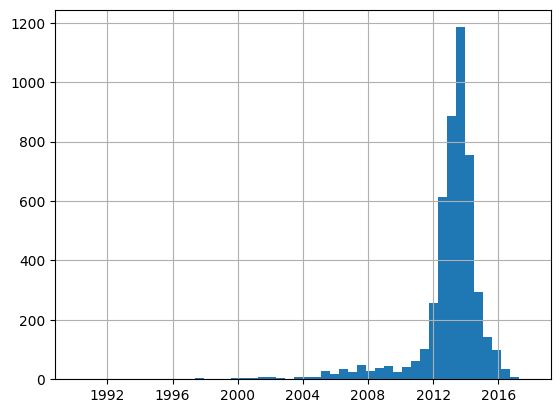

In [84]:
df_limpio['fecha_registro'].hist(bins=50)

In [85]:
df_limpio[df_limpio['fecha_registro'] < pd.Timestamp('1999-01-01')]

,modelo,km,potencia,fecha_registro,tipo_gasolina,color,tipo_coche,volante_regulable,aire_acondicionado,camara_trasera,elevalunas_electrico,bluetooth,gps,alerta_lim_velocidad,precio,fecha_venta
25,318,196092.0,85.0,1995-10-01,petrol,desconocido,convertible,True,False,False,False,False,False,False,1800.0,2018-05-01
2473,525,230578.0,85.0,1997-07-01,diesel,desconocido,sedan,False,False,False,False,False,True,False,200.0,2018-08-01
2574,525,229880.0,85.0,1997-07-01,diesel,black,sedan,False,False,False,False,False,True,False,200.0,2018-08-01
2611,525,230264.0,85.0,1997-07-01,diesel,black,sedan,False,False,False,False,False,True,False,200.0,2018-08-01
2771,316,146951.0,66.0,1990-03-01,petrol,white,sedan,False,False,False,False,False,False,False,1300.0,2018-04-01
2829,525,439060.0,105.0,1997-01-01,diesel,silver,estate,False,False,True,False,False,True,False,100.0,2018-03-01
3062,318,98097.0,85.0,1994-01-01,petrol,blue,sedan,True,False,False,False,False,True,True,400.0,2018-04-01
3380,525,245302.0,105.0,1997-01-01,diesel,green,estate,False,True,False,False,False,True,True,900.0,2018-06-01


In [86]:
df_inicial_test[df_inicial_test['fecha_registro'] < pd.Timestamp('1999-01-01')]

,marca,modelo,km,potencia,fecha_registro,tipo_gasolina,color,tipo_coche,volante_regulable,aire_acondicionado,camara_trasera,asientos_traseros_plegables,elevalunas_electrico,bluetooth,gps,alerta_lim_velocidad,precio,fecha_venta
25,BMW,318,196092.0,85.0,1995-10-01,petrol,NaN,convertible,True,False,False,False,False,False,False,False,1800.0,2018-05-01
2473,BMW,525,230578.0,85.0,1997-07-01,diesel,NaN,sedan,False,NaN,False,False,False,False,True,NaN,200.0,2018-08-01
2574,BMW,525,229880.0,85.0,1997-07-01,diesel,black,sedan,False,NaN,False,False,False,NaN,True,False,200.0,2018-08-01
2611,BMW,525,230264.0,85.0,1997-07-01,diesel,black,sedan,False,False,False,False,False,False,True,False,200.0,2018-08-01
2771,BMW,316,146951.0,66.0,1990-03-01,petrol,white,sedan,False,False,False,NaN,False,False,False,False,1300.0,2018-04-01
3062,BMW,318,98097.0,85.0,1994-01-01,petrol,blue,sedan,True,False,False,False,False,False,True,True,400.0,2018-04-01
3380,BMW,525,245302.0,105.0,1997-01-01,diesel,green,NaN,False,True,False,NaN,False,False,True,True,900.0,2018-06-01


In [55]:
df_limpio[df_limpio['fecha_registro'] > df_limpio['fecha_venta']]

,modelo,km,potencia,fecha_registro,tipo_gasolina,color,tipo_coche,volante_regulable,aire_acondicionado,camara_trasera,elevalunas_electrico,bluetooth,gps,alerta_lim_velocidad,precio,fecha_venta
42,330,142483.0,180.0,2013-05-01,diesel,blue,convertible,True,True,False,True,False,True,True,15800.0,2007-08-01
100,320,342768.0,135.0,2011-12-01,diesel,black,estate,False,True,False,True,False,True,True,8200.0,2010-04-01
180,320,181052.0,120.0,2013-06-01,diesel,black,estate,False,True,False,False,False,True,False,11500.0,2009-04-01
256,316,201102.0,85.0,2013-12-01,diesel,black,estate,True,True,False,False,False,True,False,8800.0,2008-06-01


In [56]:
# Quitamos fechas incoherentes
df_limpio_2 = df_limpio_2[df_limpio_2['fecha_registro'] <= df_limpio_2['fecha_venta']]

# Calculamos antigüedad
df_limpio_2["antigüedad"] = df_limpio_2["fecha_venta"] - df_limpio_2["fecha_registro"]
df_limpio_2['antigüedad'] = df_limpio_2['antigüedad'].dt.days / 365.25
df_limpio_2 = df_limpio_2.drop(columns=['fecha_venta','fecha_registro'])

<Axes: >

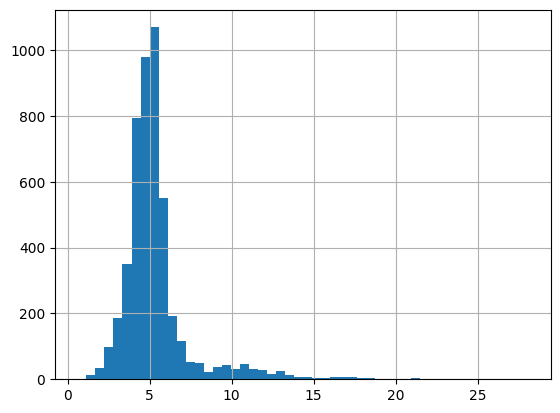

In [57]:
df_limpio_2['antigüedad'].hist(bins=50)

<Axes: >

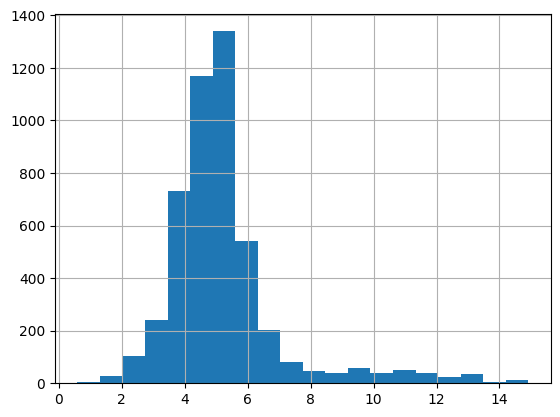

In [90]:
df_limpio_2[df_limpio_2['antigüedad'] < 15.0]['antigüedad'].hist(bins=20)

<Axes: >

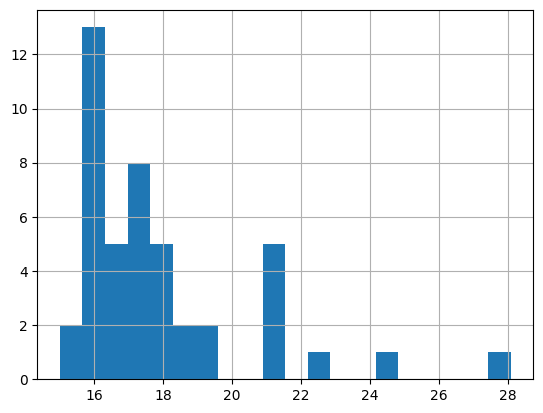

In [91]:
df_limpio_2[df_limpio_2['antigüedad'] > 15.0]['antigüedad'].hist(bins=20)

In [92]:
df_limpio_2[df_limpio_2['antigüedad'] > 15.0]['modelo'].value_counts()

,count
modelo,
320,13
318,8
520,8
525,8
316,3
530,2
X5,2
523,1


<Axes: >

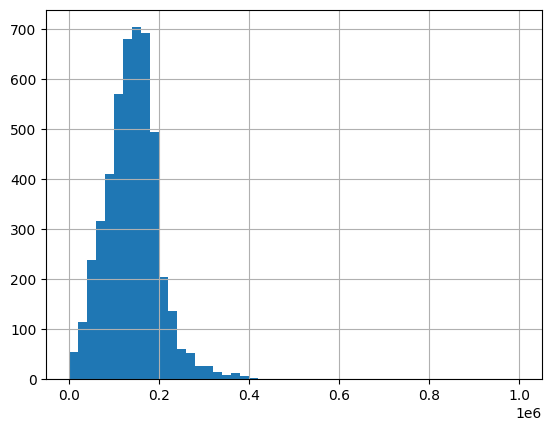

In [93]:
df_limpio_2['km'].hist(bins=50)

In [94]:
df_limpio_2[df_limpio_2['km'] < 5000.0]

,modelo,km,potencia,tipo_gasolina,color,tipo_coche,volante_regulable,aire_acondicionado,camara_trasera,elevalunas_electrico,bluetooth,gps,alerta_lim_velocidad,precio,antigüedad
471,318,3142.0,100.0,diesel,blue,estate,True,True,False,False,False,True,False,21400.0,1.418207
781,318,3478.0,100.0,diesel,blue,estate,True,True,False,False,False,True,False,21400.0,3.414100
2409,420 Gran Coupé,476.0,120.0,diesel,blue,hatchback,True,True,False,False,True,True,True,30300.0,2.250513
2938,640 Gran Coupé,-64.0,230.0,diesel,black,sedan,True,True,False,False,False,True,True,75000.0,2.332649
3687,116,2399.0,85.0,diesel,white,subcompact,False,False,False,False,False,True,False,17300.0,3.000684
3935,X5,706.0,155.0,diesel,black,suv,True,True,False,True,True,True,False,41600.0,0.588638
4146,X6 M,2970.0,423.0,petrol,red,suv,True,False,True,False,False,True,True,82400.0,1.998631
4372,X5,612.0,183.0,diesel,black,suv,True,True,False,False,False,True,True,49100.0,1.664613
4731,X5 M,4530.0,230.0,diesel,silver,suv,True,False,False,False,False,False,True,73100.0,2.083504


In [58]:
df_limpio_2[df_limpio_2['modelo'] == '640 Gran Coupé']['km'].median()

103982.0

In [96]:
df_limpio_2[df_limpio_2['km'] < 0.0]

,modelo,km,potencia,tipo_gasolina,color,tipo_coche,volante_regulable,aire_acondicionado,camara_trasera,elevalunas_electrico,bluetooth,gps,alerta_lim_velocidad,precio,antigüedad
2938,640 Gran Coupé,-64.0,230.0,diesel,black,sedan,True,True,False,False,False,True,True,75000.0,2.332649


<Axes: >

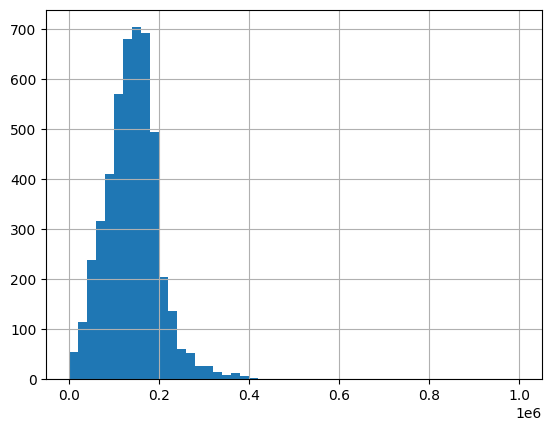

In [97]:
df_limpio_2['km'].hist(bins=50)

In [98]:
df_limpio_2[df_limpio_2['km'] < 0.0]['modelo'].iloc[0]

'640 Gran Coupé'

In [59]:
df_test = df_limpio_2.copy()
df_test.loc[df_test['km'] <= 0, 'km'] = df_test[df_test['modelo'] == df_test[df_test['km'] < 0.0]['modelo'].iloc[0]]['km'].median()
df_test.iloc[[2928]]

,modelo,km,potencia,tipo_gasolina,color,tipo_coche,volante_regulable,aire_acondicionado,camara_trasera,elevalunas_electrico,bluetooth,gps,alerta_lim_velocidad,precio,antigüedad
2938,640 Gran Coupé,103982.0,230.0,diesel,black,sedan,True,True,False,False,False,True,True,75000.0,2.332649


In [100]:
df_limpio_2[df_limpio_2['km'] > 500000.0]

,modelo,km,potencia,tipo_gasolina,color,tipo_coche,volante_regulable,aire_acondicionado,camara_trasera,elevalunas_electrico,bluetooth,gps,alerta_lim_velocidad,precio,antigüedad
3732,118,1000376.0,90.0,diesel,desconocido,hatchback,True,False,False,False,False,True,False,1400.0,13.251198


In [51]:
df_test = df_test[df_test['km'] < 500000.0]

<Axes: >

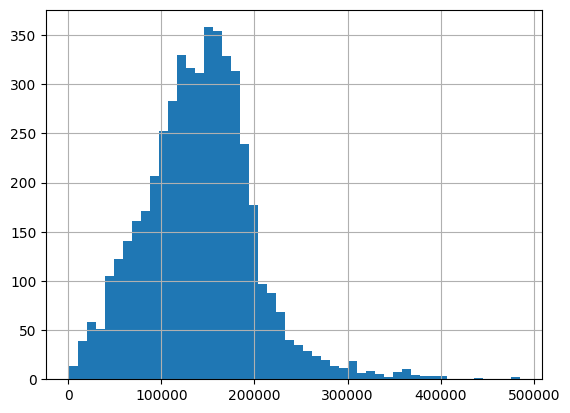

In [102]:
df_test['km'].hist(bins=50)

In [103]:
df_test[df_test['km'] > 500000.0]

,modelo,km,potencia,tipo_gasolina,color,tipo_coche,volante_regulable,aire_acondicionado,camara_trasera,elevalunas_electrico,bluetooth,gps,alerta_lim_velocidad,precio,antigüedad


<Axes: >

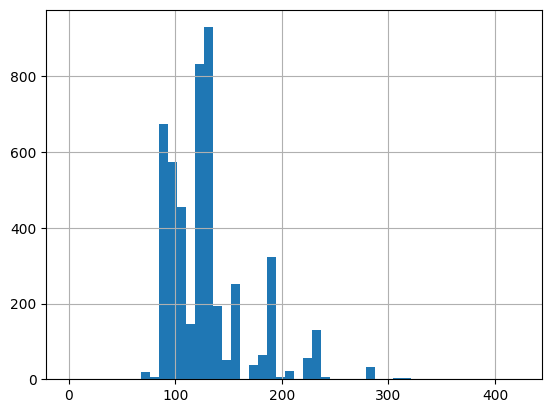

In [110]:
df_test['potencia'].hist(bins=50)

In [111]:
df_test[df_test['potencia'] < 50]

,modelo,km,potencia,tipo_gasolina,color,tipo_coche,volante_regulable,aire_acondicionado,camara_trasera,elevalunas_electrico,bluetooth,gps,alerta_lim_velocidad,precio,antigüedad
1796,i3,152328.0,25.0,hybrid_petrol,black,hatchback,False,True,False,False,False,True,True,20300.0,4.832307
1925,i3,152470.0,25.0,hybrid_petrol,black,hatchback,False,True,False,False,False,True,True,15500.0,4.747433
3765,X1,81770.0,0.0,diesel,white,suv,False,False,False,False,False,False,False,11700.0,3.414100


In [112]:
df_test.iloc[[1786, 1915, 3755]]

,modelo,km,potencia,tipo_gasolina,color,tipo_coche,volante_regulable,aire_acondicionado,camara_trasera,elevalunas_electrico,bluetooth,gps,alerta_lim_velocidad,precio,antigüedad
1796,i3,152328.0,25.0,hybrid_petrol,black,hatchback,False,True,False,False,False,True,True,20300.0,4.832307
1925,i3,152470.0,25.0,hybrid_petrol,black,hatchback,False,True,False,False,False,True,True,15500.0,4.747433
3766,X5,72677.0,180.0,diesel,grey,suv,False,False,False,False,False,False,True,23900.0,5.579740


In [47]:
df_limpio_2[(df_limpio_2['modelo'] == 'i3') & (df_limpio_2['precio'].between(15000.0, 25000.0))]['potencia'].value_counts()

,count
potencia,
25.0,2
75.0,2
125.0,1


In [52]:
df_test.loc[df_test['potencia'] < 50, 'potencia'] = None

In [115]:
df_test[df_test['potencia'].isnull()]

,modelo,km,potencia,tipo_gasolina,color,tipo_coche,volante_regulable,aire_acondicionado,camara_trasera,elevalunas_electrico,bluetooth,gps,alerta_lim_velocidad,precio,antigüedad
1796,i3,152328.0,NaN,hybrid_petrol,black,hatchback,False,True,False,False,False,True,True,20300.0,4.832307
1925,i3,152470.0,NaN,hybrid_petrol,black,hatchback,False,True,False,False,False,True,True,15500.0,4.747433
3765,X1,81770.0,NaN,diesel,white,suv,False,False,False,False,False,False,False,11700.0,3.414100


In [116]:
df_test[(df_test['modelo'] == 'i3') & (df_test['precio'].between(15000.0, 25000.0))]['potencia'].value_counts()

,count
potencia,
75.0,2
125.0,1


In [117]:
df_test[(df_test['modelo'] == 'X1') & (df_test['precio'].between(10000.0, 13000.0)) & (df_test['antigüedad'].between(2.2, 4.6))]['potencia'].value_counts(normalize=True)

,proportion
potencia,
85.0,0.500000
100.0,0.214286
105.0,0.142857
135.0,0.071429
120.0,0.071429


In [60]:
df_test = imputar_por_similitud(
            df_test, target_col='potencia', numeric_cols={'antigüedad': 0.35, 'precio': 0.1},
            cat_bool_cols=['modelo'], umbral_dominancia=0.50, estrategia='moda',
            usar_percentiles=False
        )

df_test = imputar_por_similitud(
            df_test, target_col='potencia', numeric_cols={'antigüedad': 0.35},
            cat_bool_cols=['modelo'], umbral_dominancia=0.50, estrategia='moda',
            usar_percentiles=False
        )

In [120]:
df_test.iloc[[1786, 1915, 3755]]

,modelo,km,potencia,tipo_gasolina,color,tipo_coche,volante_regulable,aire_acondicionado,camara_trasera,elevalunas_electrico,bluetooth,gps,alerta_lim_velocidad,precio,antigüedad
1796,i3,152328.0,75.0,hybrid_petrol,black,hatchback,False,True,False,False,False,True,True,20300.0,4.832307
1925,i3,152470.0,75.0,hybrid_petrol,black,hatchback,False,True,False,False,False,True,True,15500.0,4.747433
3766,X5,72677.0,180.0,diesel,grey,suv,False,False,False,False,False,False,True,23900.0,5.579740


<Axes: >

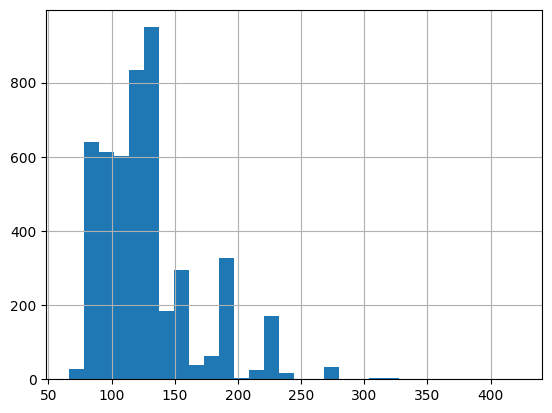

In [121]:
df_test['potencia'].hist(bins=30)

In [122]:
df_limpio_2[df_limpio_2['potencia'] > 300]

,modelo,km,potencia,tipo_gasolina,color,tipo_coche,volante_regulable,aire_acondicionado,camara_trasera,elevalunas_electrico,bluetooth,gps,alerta_lim_velocidad,precio,antigüedad
1,M4,13929.0,317.0,petrol,grey,convertible,True,True,False,False,True,True,True,69700.0,3.252567
67,M3,29925.0,309.0,petrol,silver,coupe,True,True,False,True,True,True,True,47000.0,3.331964
72,M4,69410.0,317.0,petrol,white,convertible,True,True,False,False,True,True,True,53600.0,3.077344
73,M3,170550.0,309.0,petrol,grey,coupe,True,True,False,True,False,True,True,28000.0,7.000684
93,M3,99283.0,309.0,petrol,silver,coupe,False,False,False,True,False,True,True,28600.0,4.750171
139,M3,169970.0,309.0,petrol,grey,coupe,True,True,False,True,False,True,True,35700.0,7.419576
2944,M3,33670.0,317.0,petrol,blue,sedan,True,True,False,False,True,True,True,51200.0,4.084873
3092,M3,39250.0,317.0,petrol,black,sedan,True,True,False,False,True,True,True,52400.0,2.496920
3601,M5,150187.0,412.0,petrol,white,sedan,True,True,True,True,True,True,True,41600.0,5.251198
4146,X6 M,2970.0,423.0,petrol,red,suv,True,False,True,False,False,True,True,82400.0,1.998631


<Axes: >

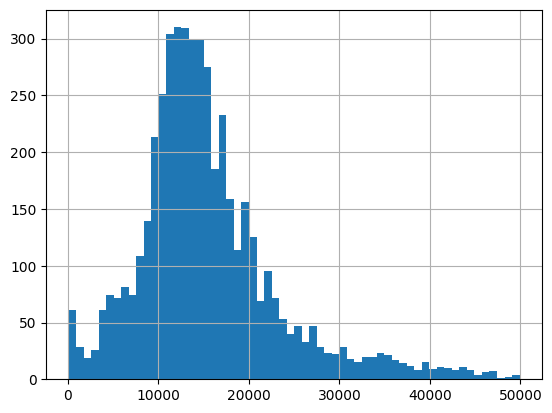

In [123]:
df_test[df_test['precio'] < 50000]['precio'].hist(bins=60)
# df_test['precio'].hist(bins=60)

<Axes: >

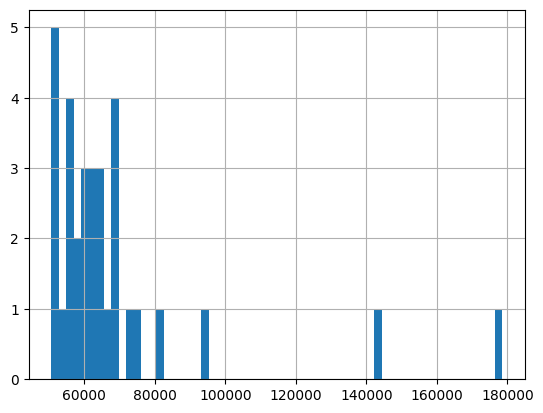

In [124]:
df_test[df_test['precio'] > 50000]['precio'].hist(bins=60)

In [125]:
df_test[df_test['precio'] > 80000]

,modelo,km,potencia,tipo_gasolina,color,tipo_coche,volante_regulable,aire_acondicionado,camara_trasera,elevalunas_electrico,bluetooth,gps,alerta_lim_velocidad,precio,antigüedad
90,i8,12402.0,170.0,hybrid_petrol,grey,coupe,True,True,False,False,False,False,True,95200.0,3.331964
4146,X6 M,2970.0,423.0,petrol,red,suv,True,False,True,False,False,True,True,82400.0,1.998631
4684,X4,103222.0,140.0,diesel,grey,suv,True,True,False,True,False,True,True,142800.0,4.000000
4753,X3,72515.0,135.0,diesel,blue,suv,False,False,True,False,False,False,True,178500.0,5.418207


In [61]:
df_test = df_test[df_test['precio'] < 100000]

In [127]:
df_test[df_test['precio'] > 80000]

,modelo,km,potencia,tipo_gasolina,color,tipo_coche,volante_regulable,aire_acondicionado,camara_trasera,elevalunas_electrico,bluetooth,gps,alerta_lim_velocidad,precio,antigüedad
90,i8,12402.0,170.0,hybrid_petrol,grey,coupe,True,True,False,False,False,False,True,95200.0,3.331964
4146,X6 M,2970.0,423.0,petrol,red,suv,True,False,True,False,False,True,True,82400.0,1.998631


<Axes: >

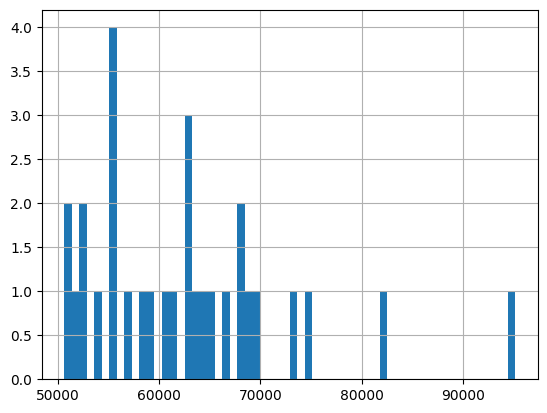

In [128]:
df_test[df_test['precio'] > 50000]['precio'].hist(bins=60)

In [129]:
df_test[df_test['modelo'].map(df_test['modelo'].value_counts()) < 2]

,modelo,km,potencia,tipo_gasolina,color,tipo_coche,volante_regulable,aire_acondicionado,camara_trasera,elevalunas_electrico,bluetooth,gps,alerta_lim_velocidad,precio,antigüedad
55,225,78638.0,160.0,diesel,black,coupe,False,True,False,False,True,True,True,18300.0,4.251882
90,i8,12402.0,170.0,hybrid_petrol,grey,coupe,True,True,False,False,False,False,True,95200.0,3.331964
107,630,149943.0,190.0,petrol,black,coupe,True,True,True,True,True,True,True,10500.0,4.914442
142,635,173302.0,210.0,diesel,grey,coupe,True,True,True,True,False,True,True,19300.0,8.251882
1899,M135,94497.0,239.0,petrol,grey,hatchback,True,False,False,True,False,True,False,25700.0,3.756331
2925,ActiveHybrid 5,94374.0,225.0,hybrid_petrol,brown,sedan,True,True,False,True,True,True,True,21100.0,5.916496
3154,735,184189.0,200.0,petrol,grey,sedan,True,True,False,False,False,True,True,4500.0,5.166324
3601,M5,150187.0,412.0,petrol,white,sedan,True,True,True,True,True,True,True,41600.0,5.251198
4803,216,31079.0,85.0,diesel,black,van,False,True,False,False,False,False,False,4800.0,3.329227
4804,220 Active Tourer,153358.0,140.0,diesel,grey,van,False,False,False,False,False,True,True,11700.0,2.672142


In [130]:
df_test[(df_test['modelo'].str.endswith('Active Tourer'))]

,modelo,km,potencia,tipo_gasolina,color,tipo_coche,volante_regulable,aire_acondicionado,camara_trasera,elevalunas_electrico,bluetooth,gps,alerta_lim_velocidad,precio,antigüedad
4799,218 Active Tourer,35888.0,100.0,diesel,blue,van,False,True,False,False,False,True,False,16200.0,2.833676
4804,220 Active Tourer,153358.0,140.0,diesel,grey,van,False,False,False,False,False,True,True,11700.0,2.672142
4805,218 Active Tourer,35382.0,110.0,diesel,desconocido,van,False,True,False,False,False,True,True,13100.0,2.672142
4807,218 Active Tourer,197276.0,112.0,diesel,white,van,True,True,False,False,False,True,True,13100.0,5.336071
4810,216 Active Tourer,193657.0,85.0,diesel,silver,van,False,False,False,False,False,True,False,8900.0,3.504449
4813,216 Active Tourer,117375.0,85.0,diesel,black,van,False,True,False,False,False,True,False,12300.0,2.833676
4820,Active Tourer,48380.0,100.0,diesel,black,van,True,False,False,False,False,True,False,19000.0,3.581109
4821,218 Active Tourer,91512.0,100.0,petrol,white,van,False,True,True,False,False,True,False,14300.0,2.915811
4822,218 Active Tourer,153159.0,110.0,diesel,black,van,False,True,False,False,False,False,False,13200.0,4.914442
4823,218 Active Tourer,150904.0,112.0,diesel,black,van,True,True,False,False,False,True,False,11800.0,4.914442


In [131]:
df_test[(df_test['modelo'].str.endswith('Active Tourer')) & (df_test['antigüedad'].between(2.5, 4.5)) & (df_test['potencia'] == 100.0)]#['modelo'].value_counts()

,modelo,km,potencia,tipo_gasolina,color,tipo_coche,volante_regulable,aire_acondicionado,camara_trasera,elevalunas_electrico,bluetooth,gps,alerta_lim_velocidad,precio,antigüedad
4799,218 Active Tourer,35888.0,100.0,diesel,blue,van,False,True,False,False,False,True,False,16200.0,2.833676
4820,Active Tourer,48380.0,100.0,diesel,black,van,True,False,False,False,False,True,False,19000.0,3.581109
4821,218 Active Tourer,91512.0,100.0,petrol,white,van,False,True,True,False,False,True,False,14300.0,2.915811
4827,218 Active Tourer,65689.0,100.0,diesel,grey,van,False,True,False,False,False,True,True,17300.0,3.000684
4831,218 Active Tourer,43278.0,100.0,diesel,black,van,False,True,False,False,False,True,True,17100.0,3.167693
4836,218 Active Tourer,81230.0,100.0,diesel,black,van,False,True,False,False,False,True,False,14200.0,3.000684
4839,218 Active Tourer,49832.0,100.0,diesel,grey,van,False,True,False,False,False,True,True,17500.0,3.167693


In [132]:
df_test.loc[[4820]]

,modelo,km,potencia,tipo_gasolina,color,tipo_coche,volante_regulable,aire_acondicionado,camara_trasera,elevalunas_electrico,bluetooth,gps,alerta_lim_velocidad,precio,antigüedad
4820,Active Tourer,48380.0,100.0,diesel,black,van,True,False,False,False,False,True,False,19000.0,3.581109


In [133]:
df_test.loc[df_test['modelo'] == ' Active Tourer', 'modelo'] = '218 Active Tourer'
df_test.loc[[4820]]

,modelo,km,potencia,tipo_gasolina,color,tipo_coche,volante_regulable,aire_acondicionado,camara_trasera,elevalunas_electrico,bluetooth,gps,alerta_lim_velocidad,precio,antigüedad
4820,218 Active Tourer,48380.0,100.0,diesel,black,van,True,False,False,False,False,True,False,19000.0,3.581109


<Axes: >

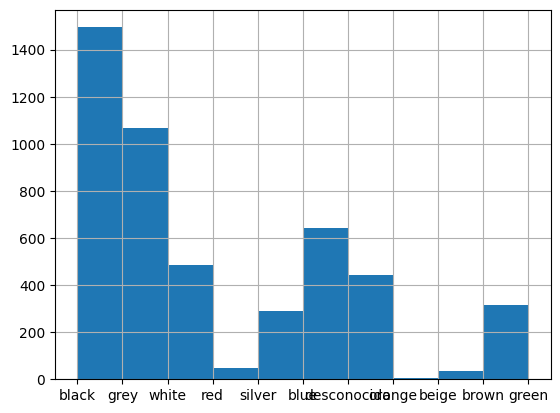

In [134]:
df_test['color'].hist()

<Axes: >

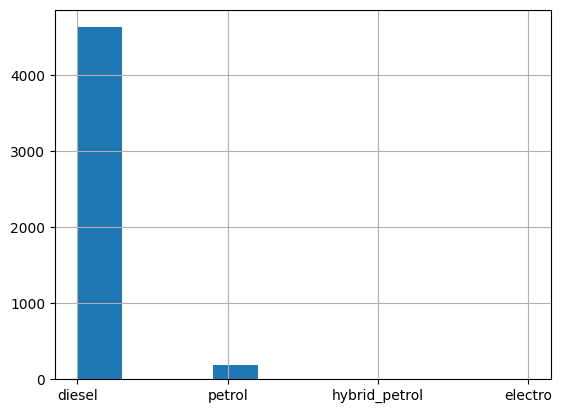

In [135]:
df_test['tipo_gasolina'].hist()

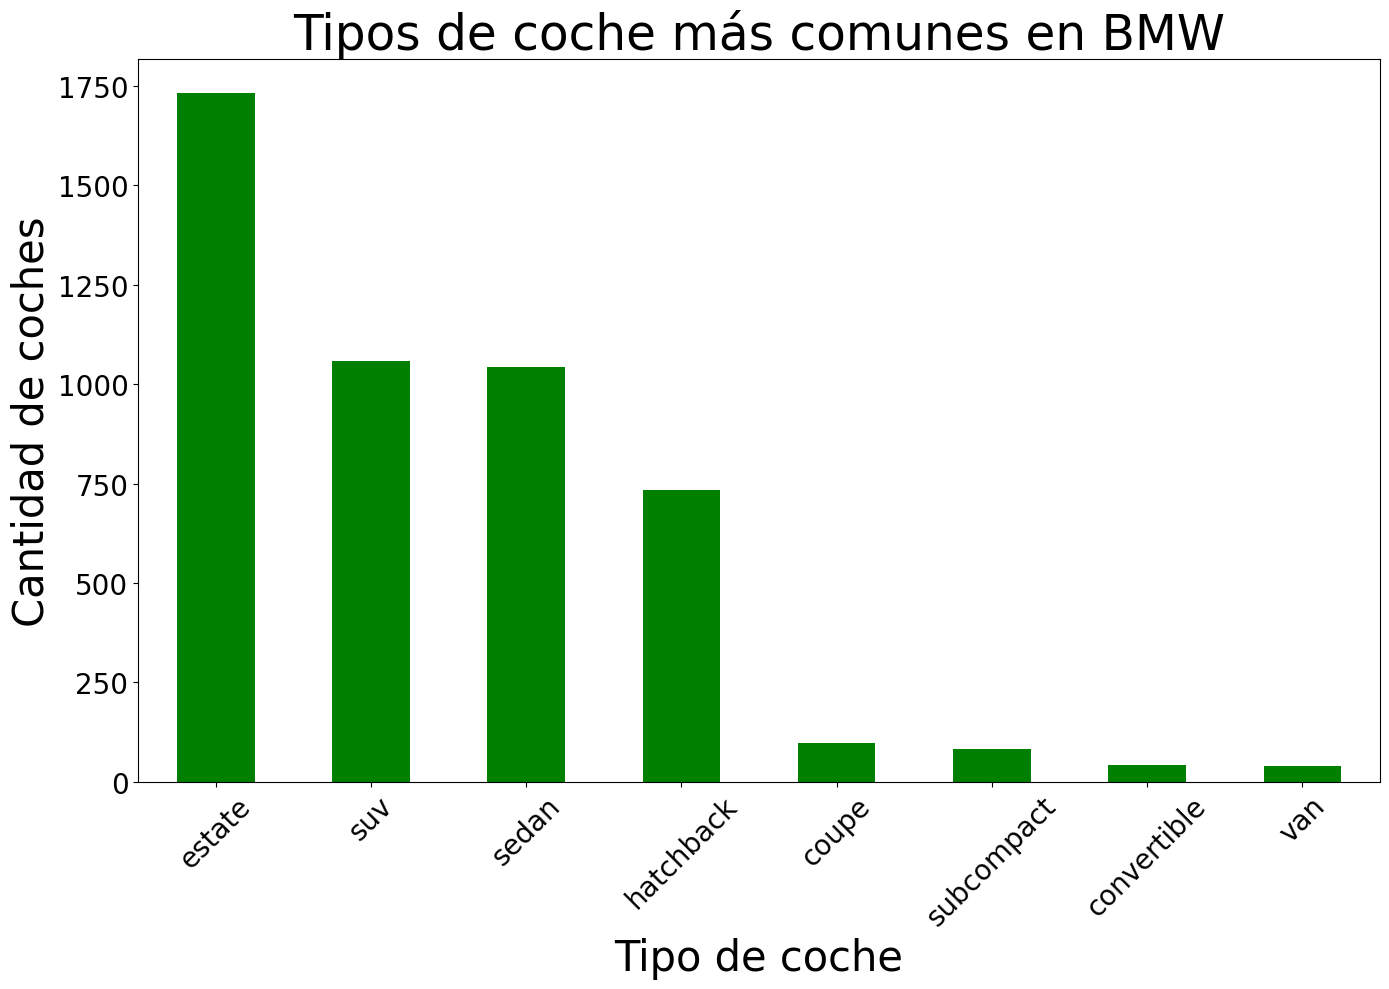

In [136]:
plt.figure(figsize=(14, 10))
df_test['tipo_coche'].value_counts().plot(kind='bar', color='green')
plt.title('Tipos de coche más comunes en BMW', fontsize=35)
plt.xlabel('Tipo de coche', fontsize=30)
plt.ylabel('Cantidad de coches', fontsize=30)
plt.xticks(rotation=45, fontsize=20)
plt.yticks(fontsize=20)
plt.tight_layout()
plt.show()

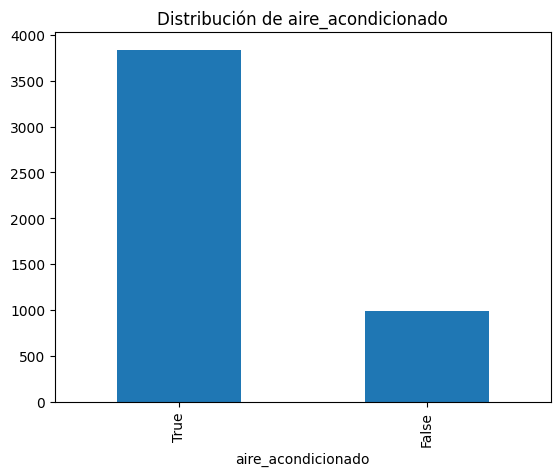

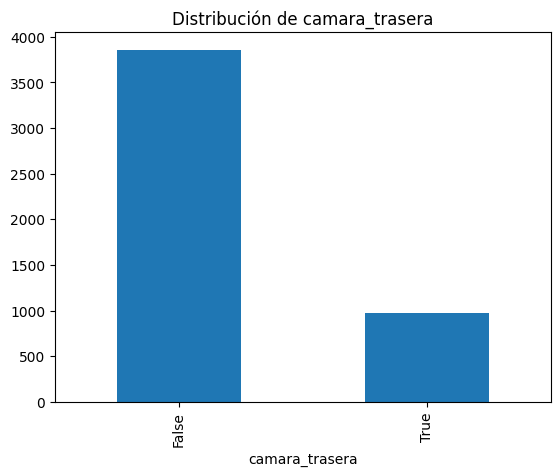

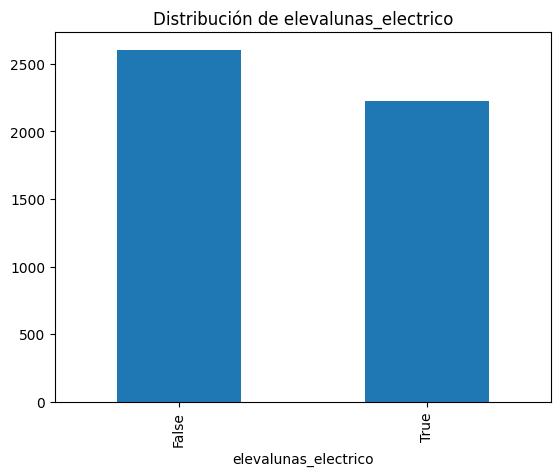

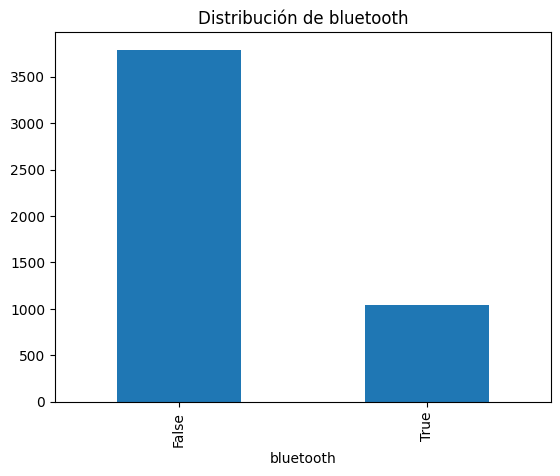

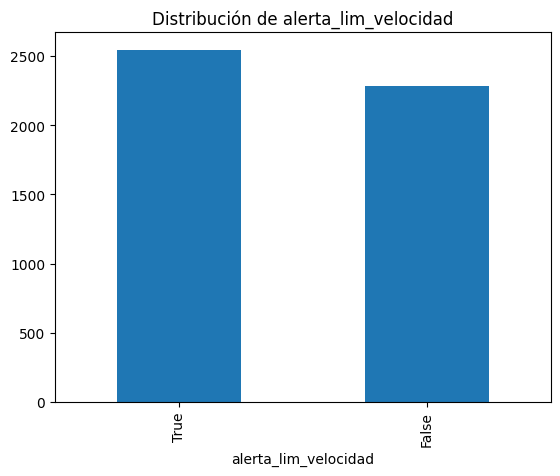

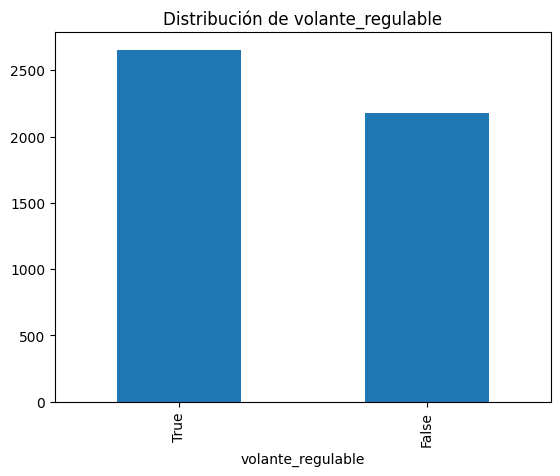

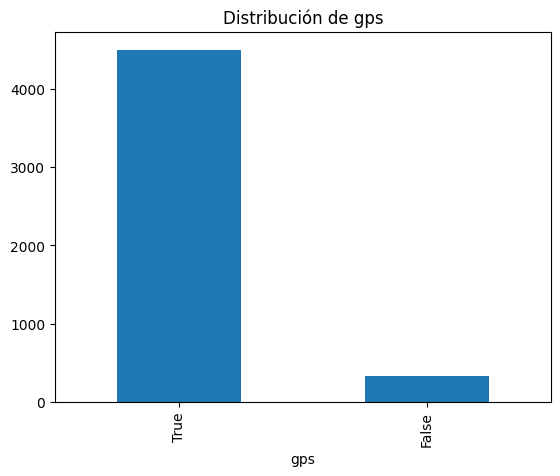

In [137]:
for col in target_equipamiento:
    plt.figure()  # Crea un lienzo nuevo en cada vuelta
    df_test[col].value_counts().plot(kind='bar', title=f'Distribución de {col}')
    plt.show()    # Fuerza a que se pinte ahora mismo

Tiene más probabilidad de tener gps que un elevalunas eléctrico

---

# **4. Análisis de correlación inicial, ¿Hay alguna variable correlacionada?**

In [53]:
df_corr = df_test.copy()
for col in target_equipamiento:
    if col in df_corr.columns:
        # Convertimos 1.0 -> True, 0.0 -> False
        df_corr[col] = df_corr[col].astype(bool)

In [139]:
corr_bool = df_corr[target_equipamiento].corr(numeric_only = True)
corr_bool.style.background_gradient(cmap='cividis')

,aire_acondicionado,camara_trasera,elevalunas_electrico,bluetooth,alerta_lim_velocidad,volante_regulable,gps
aire_acondicionado,1.000000,0.136516,0.255994,0.105698,0.204393,0.288727,0.339441
camara_trasera,0.136516,1.000000,0.199640,0.139714,0.194288,0.255392,0.063759
elevalunas_electrico,0.255994,0.199640,1.000000,0.238853,0.333367,0.277961,0.203230
bluetooth,0.105698,0.139714,0.238853,1.000000,0.099896,0.132348,0.117465
alerta_lim_velocidad,0.204393,0.194288,0.333367,0.099896,1.000000,0.221668,-0.067640
volante_regulable,0.288727,0.255392,0.277961,0.132348,0.221668,1.000000,0.243637
gps,0.339441,0.063759,0.203230,0.117465,-0.067640,0.243637,1.000000


In [140]:
cols_numericas = ['precio', 'km', 'potencia', 'antigüedad']
corr_num = df_corr[cols_numericas].corr(numeric_only = True)
corr_num.style.background_gradient(cmap='cividis')

,precio,km,potencia,antigüedad
precio,1.000000,-0.429030,0.675123,-0.422036
km,-0.429030,1.000000,-0.048185,0.540194
potencia,0.675123,-0.048185,1.000000,-0.098234
antigüedad,-0.422036,0.540194,-0.098234,1.000000


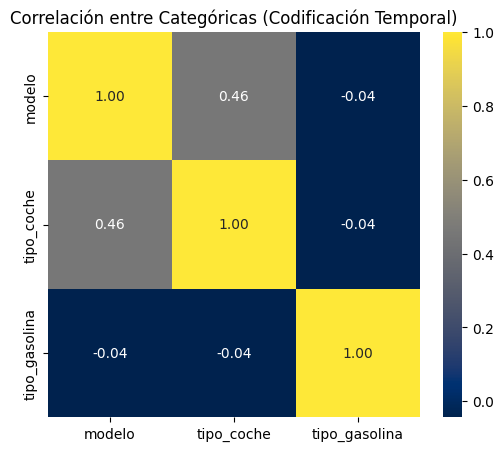

In [141]:
# 1. Creamos una copia para no dañar el dataset original
df_cat_numerica = df_corr[target_estructural].copy()

# 2. Convertimos texto a números (Factorize)
# Esto asigna 0, 1, 2... a cada categoría única
for col in target_estructural:
    df_cat_numerica[col] = pd.factorize(df_cat_numerica[col])[0]

# 3. Ahora sí podemos hacer la correlación (Usamos Spearman porque no son lineales)
corr_cat = df_cat_numerica.corr(method='spearman')

# 4. Visualización
plt.figure(figsize=(6, 5))
sns.heatmap(corr_cat, annot=True, cmap='cividis', fmt=".2f")
plt.title('Correlación entre Categóricas (Codificación Temporal)')
plt.show()

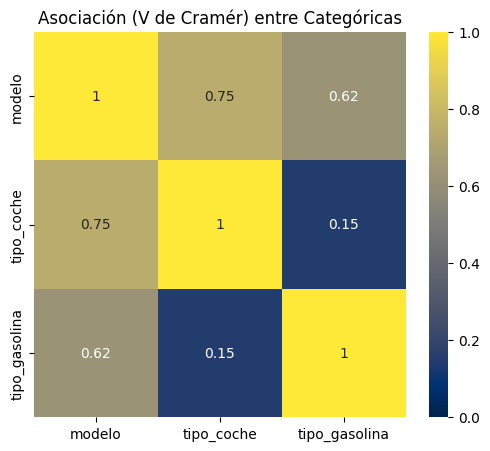

In [142]:
import scipy.stats as ss

def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = ss.chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    phi2corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))
    rcorr = r - ((r-1)**2)/(n-1)
    kcorr = k - ((k-1)**2)/(n-1)
    return np.sqrt(phi2corr / min((kcorr-1), (rcorr-1)))

# Calcular la matriz
cols = target_estructural # ['modelo', 'tipo_coche', 'tipo_gasolina']
cramer_matrix = pd.DataFrame(index=cols, columns=cols, dtype=float)

for col1 in cols:
    for col2 in cols:
        cramer_matrix.loc[col1, col2] = cramers_v(df_test[col1], df_test[col2])

# Visualizar
plt.figure(figsize=(6, 5))
sns.heatmap(cramer_matrix, annot=True, cmap='cividis', vmin=0, vmax=1)
plt.title('Asociación (V de Cramér) entre Categóricas')
plt.show()

In [ ]:
# Lo que podemos comprobar en el siguiente mapa de correlación y analizando sobretodo las variables numéricas, lo que podemos comprobar es que los kilometros presentan una correlación negativa con
# respecto al precio, es decir, que cuando el coche aumenta los kilométros recorridos, el precio de éste disminuye. Por otro lado, la potencia tiene una correlación bastante alta con el precio,
# entendiendóse que contra más potencia tiene el coche, más alto será su precio. Tenemos también algunas de las variables booleanas que nos han salido con una correlación con el precio de
# aproximadamente 0,25; lo que, nos da a entender que tienen una pequeña correlación, y que, cuando disponemos de algunos de estos artilugios en el coche, su precio será mayor.

In [ ]:
# Las demás variables no son numéricas, sino booleanas, sin embargo, las pasamos a categoricas para hacer el mapa de correlación.

In [146]:
# Lista de todas las variables booleanas
variables_booleanas = ['volante_regulable', 'camara_trasera', 'elevalunas_electrico',
                       'bluetooth', 'gps', 'alerta_lim_velocidad']

# Análisis para cada variable
for variable in variables_booleanas:
    print(f"\n📊 ANÁLISIS DE {variable.upper()}")
    print("="*40)

    # 1. Filtrar solo True (1) y False (0)
    if variable == 'alerta_lim_velocidad':
        datos_filtrados = df_test[df_test[variable].isin([0, 1])]
    else:
        # Para otras booleanas, True=1, False=0
        datos_filtrados = df_test

    # 2. Contar cuántos hay de cada
    print(f"\nCantidad de coches:")
    print(f"False (0): {(datos_filtrados[variable] == 0).sum()}")
    print(f"True (1): {(datos_filtrados[variable] == 1).sum()}")

    # 3. Porcentajes
    total = len(datos_filtrados)
    print(f"\nPorcentajes:")
    print(f"False: {(datos_filtrados[variable] == 0).sum()/total*100:.1f}%")
    print(f"True: {(datos_filtrados[variable] == 1).sum()/total*100:.1f}%")

    # 4. Ver precio promedio
    print(f"\n💰 Precio promedio:")
    print(f"False: €{datos_filtrados[datos_filtrados[variable] == 0]['precio'].mean():,.0f}")
    print(f"True: €{datos_filtrados[datos_filtrados[variable] == 1]['precio'].mean():,.0f}")

    print("-" * 40)


📊 ANÁLISIS DE VOLANTE_REGULABLE

Cantidad de coches:
False (0): 2175
True (1): 2655

Porcentajes:
False: 45.0%
True: 55.0%

💰 Precio promedio:
False: €13,021
True: €18,038
----------------------------------------

📊 ANÁLISIS DE CAMARA_TRASERA

Cantidad de coches:
False (0): 3857
True (1): 973

Porcentajes:
False: 79.9%
True: 20.1%

💰 Precio promedio:
False: €14,641
True: €20,291
----------------------------------------

📊 ANÁLISIS DE ELEVALUNAS_ELECTRICO

Cantidad de coches:
False (0): 2605
True (1): 2225

Porcentajes:
False: 53.9%
True: 46.1%

💰 Precio promedio:
False: €13,542
True: €18,398
----------------------------------------

📊 ANÁLISIS DE BLUETOOTH

Cantidad de coches:
False (0): 3789
True (1): 1041

Porcentajes:
False: 78.4%
True: 21.6%

💰 Precio promedio:
False: €14,786
True: €19,393
----------------------------------------

📊 ANÁLISIS DE GPS

Cantidad de coches:
False (0): 328
True (1): 4502

Porcentajes:
False: 6.8%
True: 93.2%

💰 Precio promedio:
False: €15,515
True: €15,

---

# **5. Análisis variable vs target, ¿Hay algún insight interesante?**


<Figure size 1500x500 with 0 Axes>

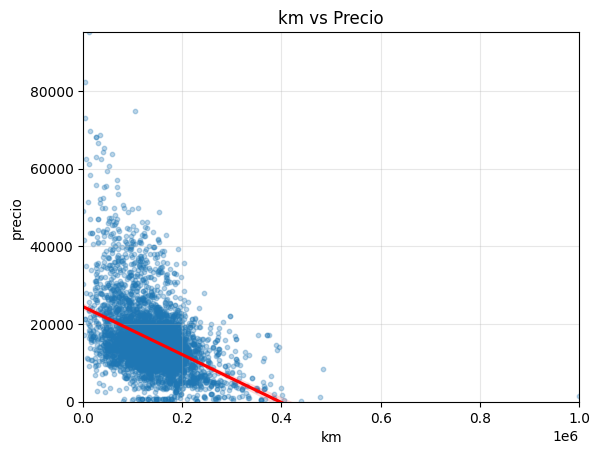

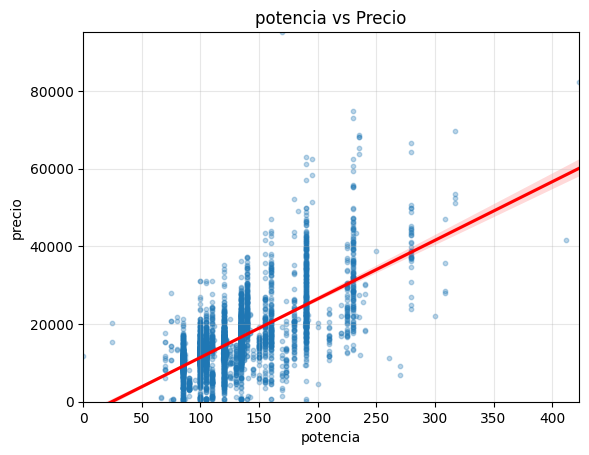

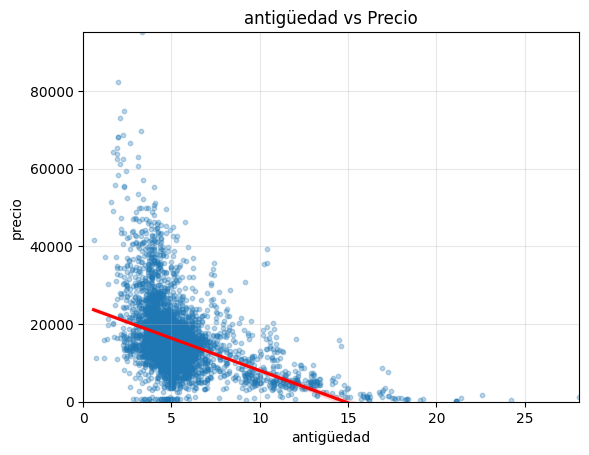

<Figure size 640x480 with 0 Axes>

In [62]:
df_analisis = df_test.copy() # O df_inicial_test_knn, el que estés usando

# Variables numéricas continuas
nums = ['km', 'potencia', 'antigüedad']

plt.figure(figsize=(15, 5))

for i, col in enumerate(nums):
    plt.figure()
    # Usamos regplot para ver la línea de tendencia automáticamente
    sns.regplot(x=col, y='precio', data=df_analisis,
                scatter_kws={'alpha':0.3, 's':10}, line_kws={'color':'red'})
    plt.title(f'{col} vs Precio')
    plt.grid(True, alpha=0.3)
    plt.axis([0, max(df_analisis[col]), 0, max(df_analisis['precio'])])
    plt.show()

plt.tight_layout()
plt.show()

In [ ]:
# A continuación hacemos gráficos scatterplot con las variables más relacionadas que tenemos en el mapa de correlación:
# Por un lado km con precio y por el otro potencia con precio.

In [ ]:
# En este caso, podemos ver una clara correlación negativa, cuando tenemos menos kilómetros hechos es cuando el precio más aumenta.
# Sin embargo, cuando tenemos más kilómetros recorridos, es cuando podemos encontrar un precio más bajo.

In [ ]:
# En este caso, podemos comprobar como al tener de más potencia, tenemos un precio más elevado. Garantizamos que hay presente
# una correlación positiva entre potencia y precio.

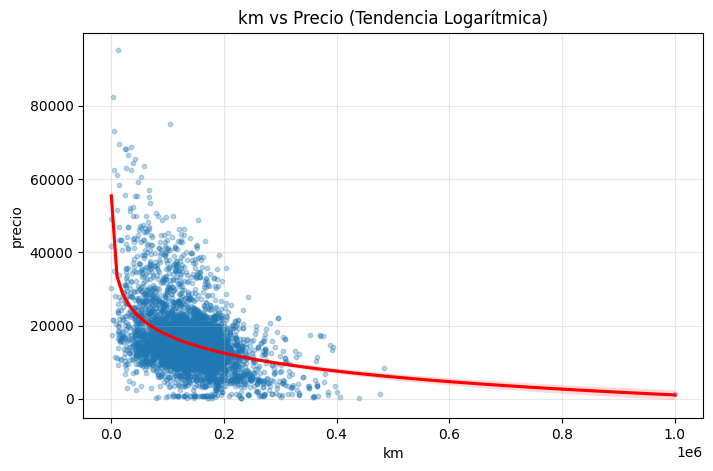

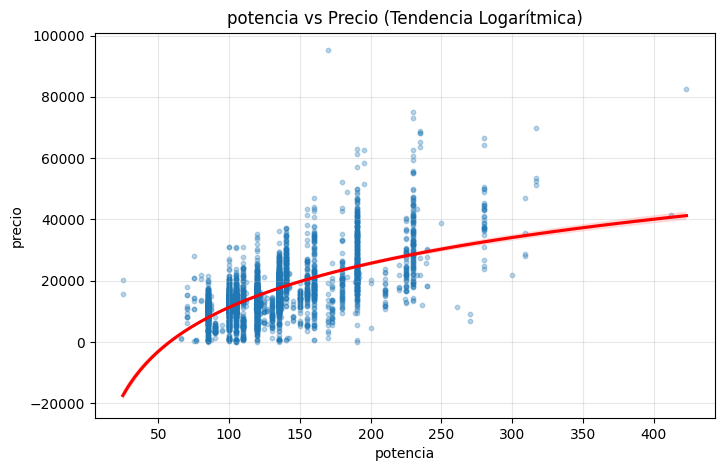

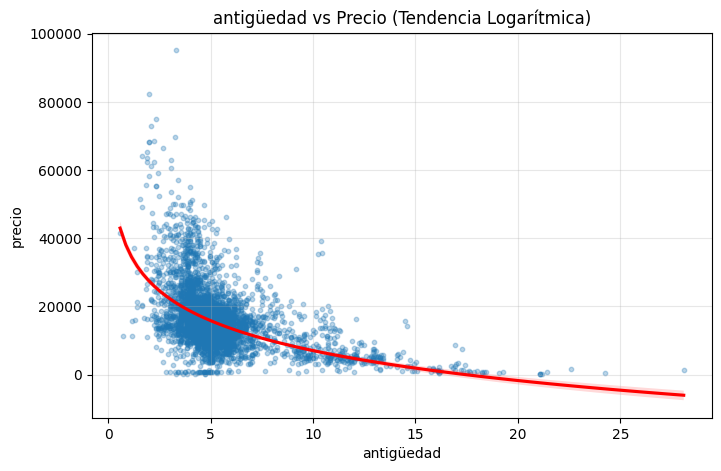

In [63]:
nums = ['km', 'potencia', 'antigüedad']

for col in nums:
    plt.figure(figsize=(8, 5))
    data_plot = df_analisis[df_analisis[col] > 0]
    sns.regplot(x=col, y='precio', data=data_plot,
                logx=True,
                scatter_kws={'alpha':0.3, 's':10},
                line_kws={'color':'red'})
    plt.title(f'{col} vs Precio (Tendencia Logarítmica)')
    plt.grid(True, alpha=0.3)
    plt.show()

/tmp/ipykernel_24447/3989895093.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=col, y='precio', data=df_analisis, palette='Set2')


<Figure size 1500x1200 with 0 Axes>

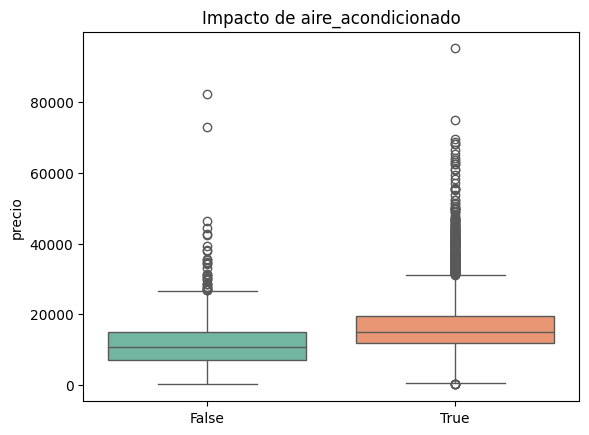

/tmp/ipykernel_24447/3989895093.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=col, y='precio', data=df_analisis, palette='Set2')


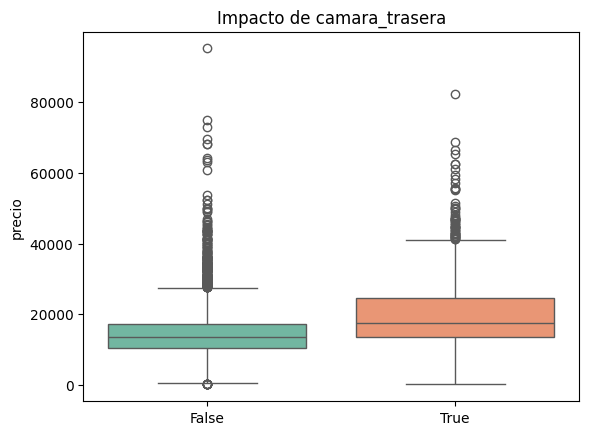

/tmp/ipykernel_24447/3989895093.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=col, y='precio', data=df_analisis, palette='Set2')


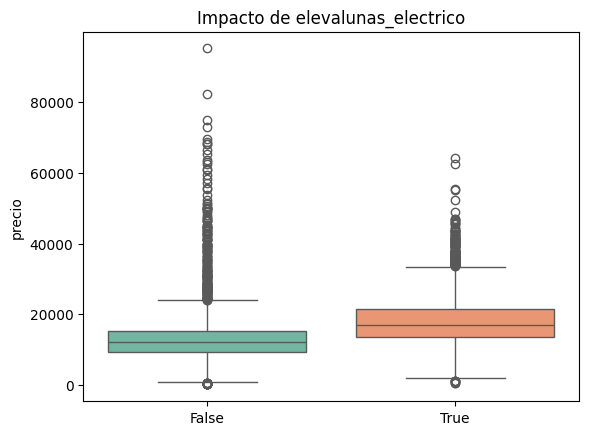

/tmp/ipykernel_24447/3989895093.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=col, y='precio', data=df_analisis, palette='Set2')


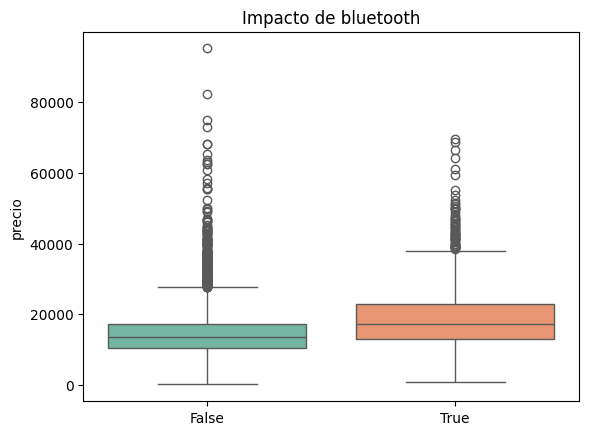

/tmp/ipykernel_24447/3989895093.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=col, y='precio', data=df_analisis, palette='Set2')


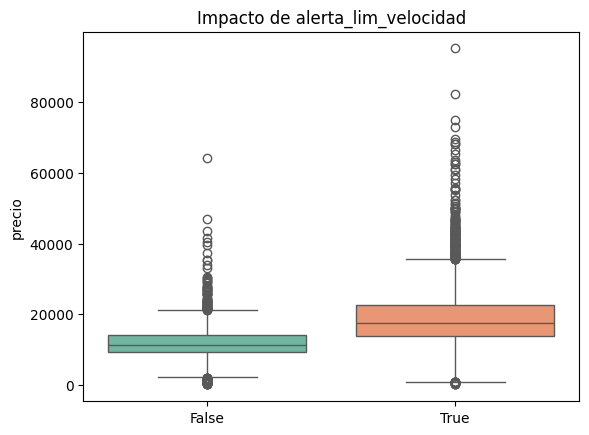

/tmp/ipykernel_24447/3989895093.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=col, y='precio', data=df_analisis, palette='Set2')


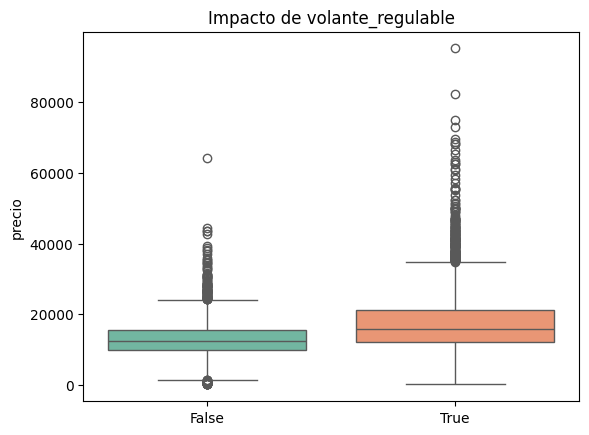

/tmp/ipykernel_24447/3989895093.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=col, y='precio', data=df_analisis, palette='Set2')


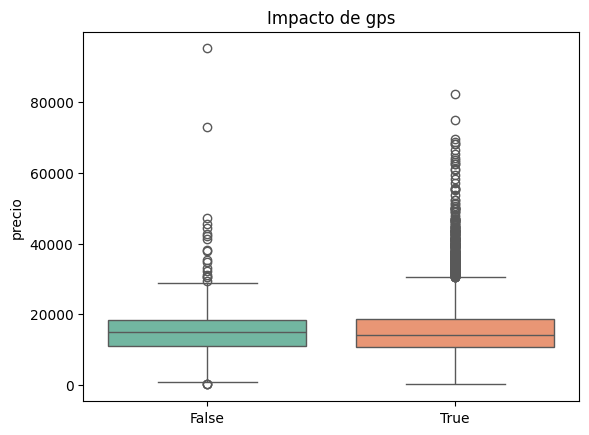

<Figure size 640x480 with 0 Axes>

In [64]:
# Lista de equipamiento
cols_equip = target_equipamiento # ['aire_acondicionado', 'gps', etc.]

# Configuración del grid para pintar muchos gráficos
n_cols = 3
n_rows = (len(cols_equip) + n_cols - 1) // n_cols

plt.figure(figsize=(15, n_rows * 4))

for i, col in enumerate(cols_equip):
    plt.figure()
    # Boxplot: Compara la distribución de precios si TIENE o NO TIENE el extra
    sns.boxplot(x=col, y='precio', data=df_analisis, palette='Set2')
    plt.title(f'Impacto de {col}')
    plt.xlabel('') # Quitamos etiqueta x para limpiar
    plt.show()

plt.tight_layout()
plt.show()

/tmp/ipykernel_24447/1398135763.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(y='modelo', x='precio', data=data_to_plot, order=order, palette='Set2')


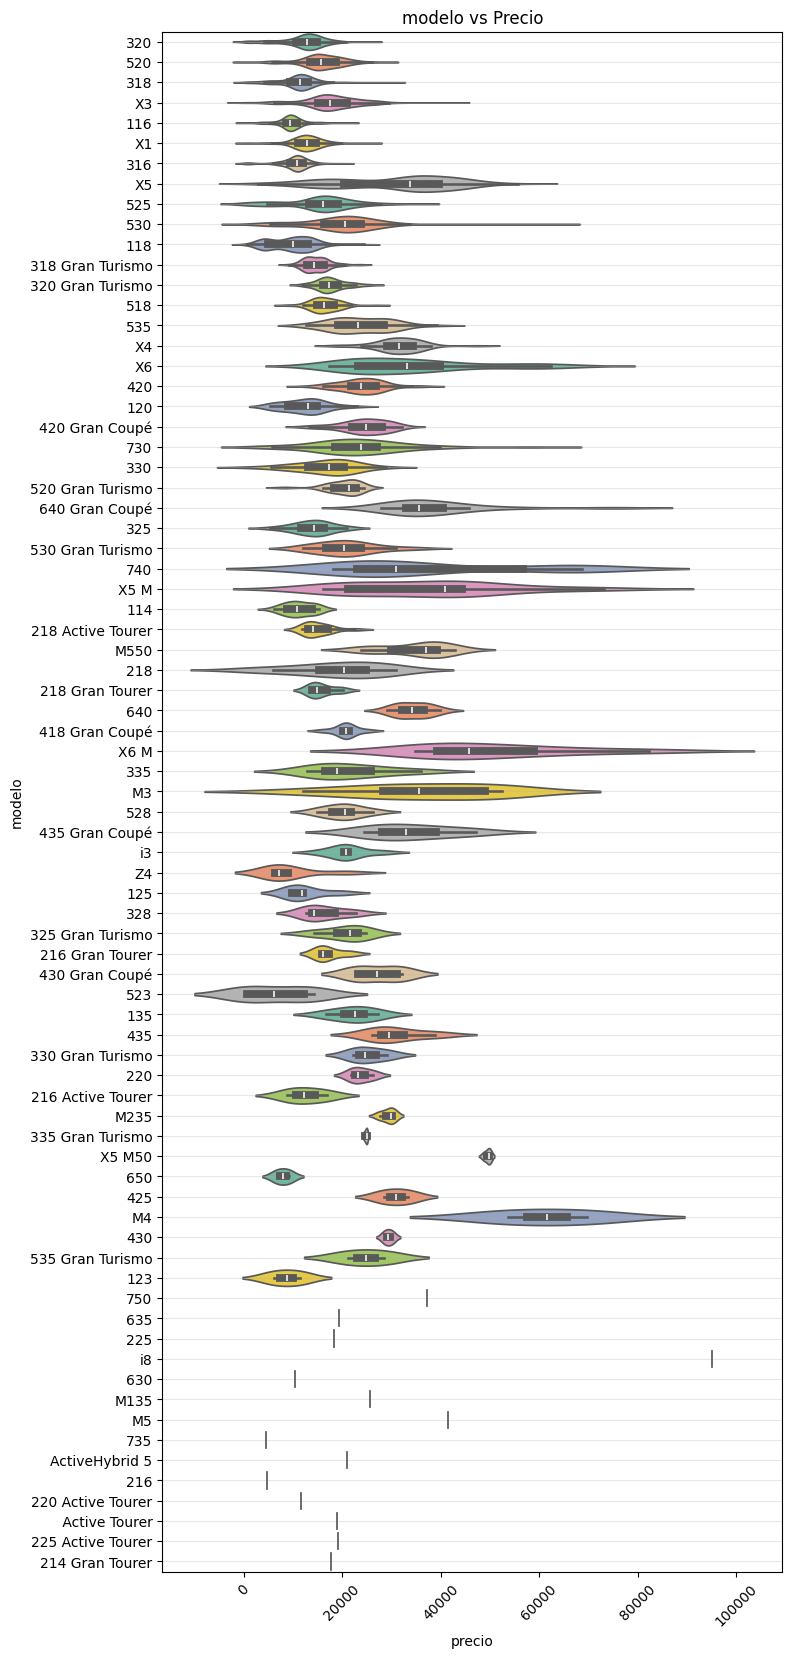

In [65]:
plt.figure(figsize=(8, 20))
top_n = df_analisis['modelo'].value_counts().index
data_to_plot = df_analisis[df_analisis['modelo'].isin(top_n)]
order = top_n
titulo = f'{'modelo'} vs Precio'
sns.violinplot(y='modelo', x='precio', data=data_to_plot, order=order, palette='Set2')
plt.title(titulo)
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.show()

/tmp/ipykernel_24447/1978857333.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=col, y='precio', data=data_to_plot, order=order, palette='viridis')


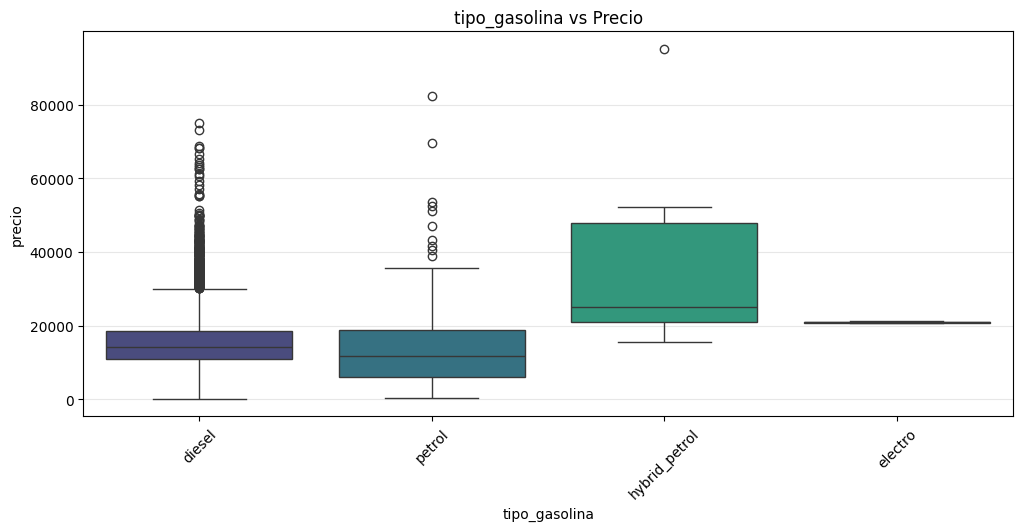

/tmp/ipykernel_24447/1978857333.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=col, y='precio', data=data_to_plot, order=order, palette='viridis')


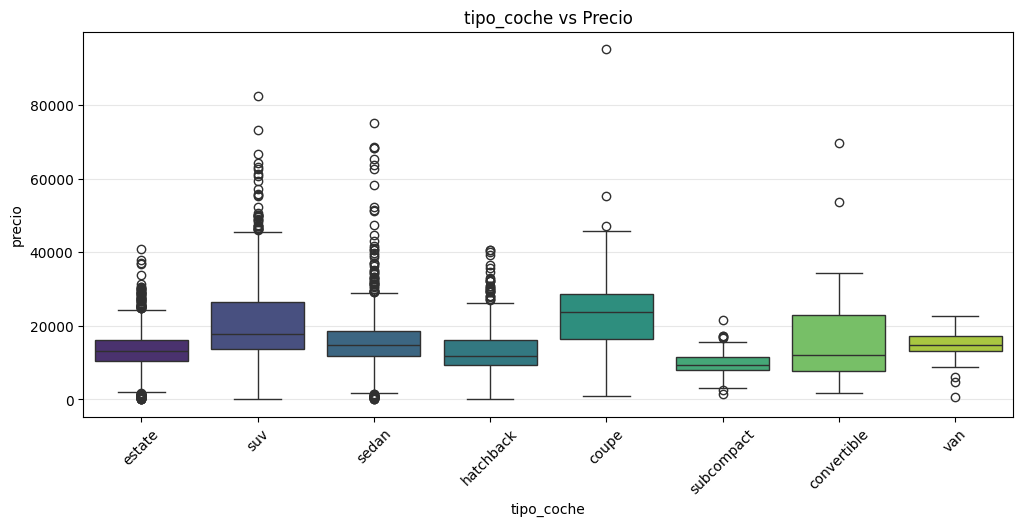

/tmp/ipykernel_24447/1978857333.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=col, y='precio', data=data_to_plot, order=order, palette='viridis')


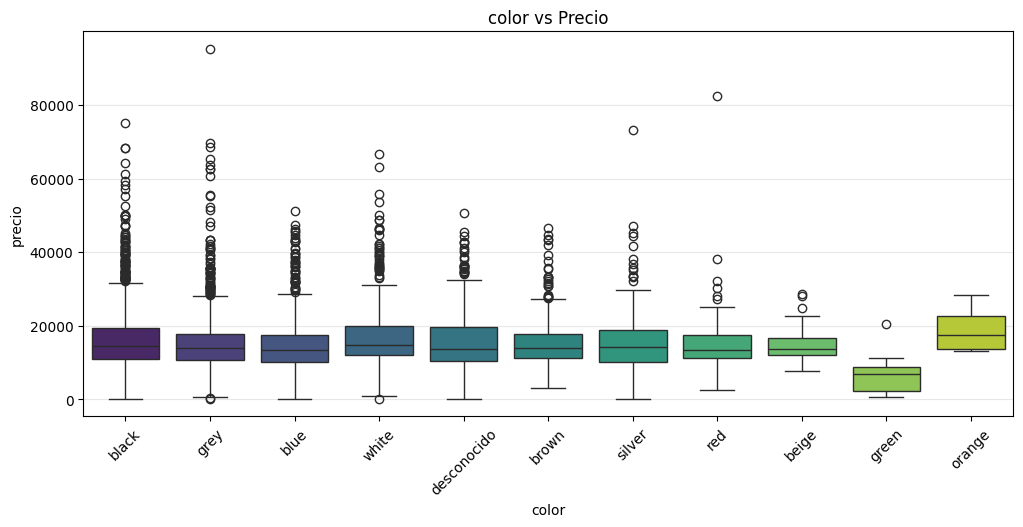

In [66]:
cols_cat = ['tipo_gasolina', 'tipo_coche', 'color']

for col in cols_cat:
    plt.figure(figsize=(12, 5))
    data_to_plot = df_analisis
    order = df_analisis[col].value_counts().index # Ordenar por frecuencia
    titulo = f'{col} vs Precio'
    sns.boxplot(x=col, y='precio', data=data_to_plot, order=order, palette='viridis')
    plt.title(titulo)
    plt.xticks(rotation=45)
    plt.grid(axis='y', alpha=0.3)
    plt.show()

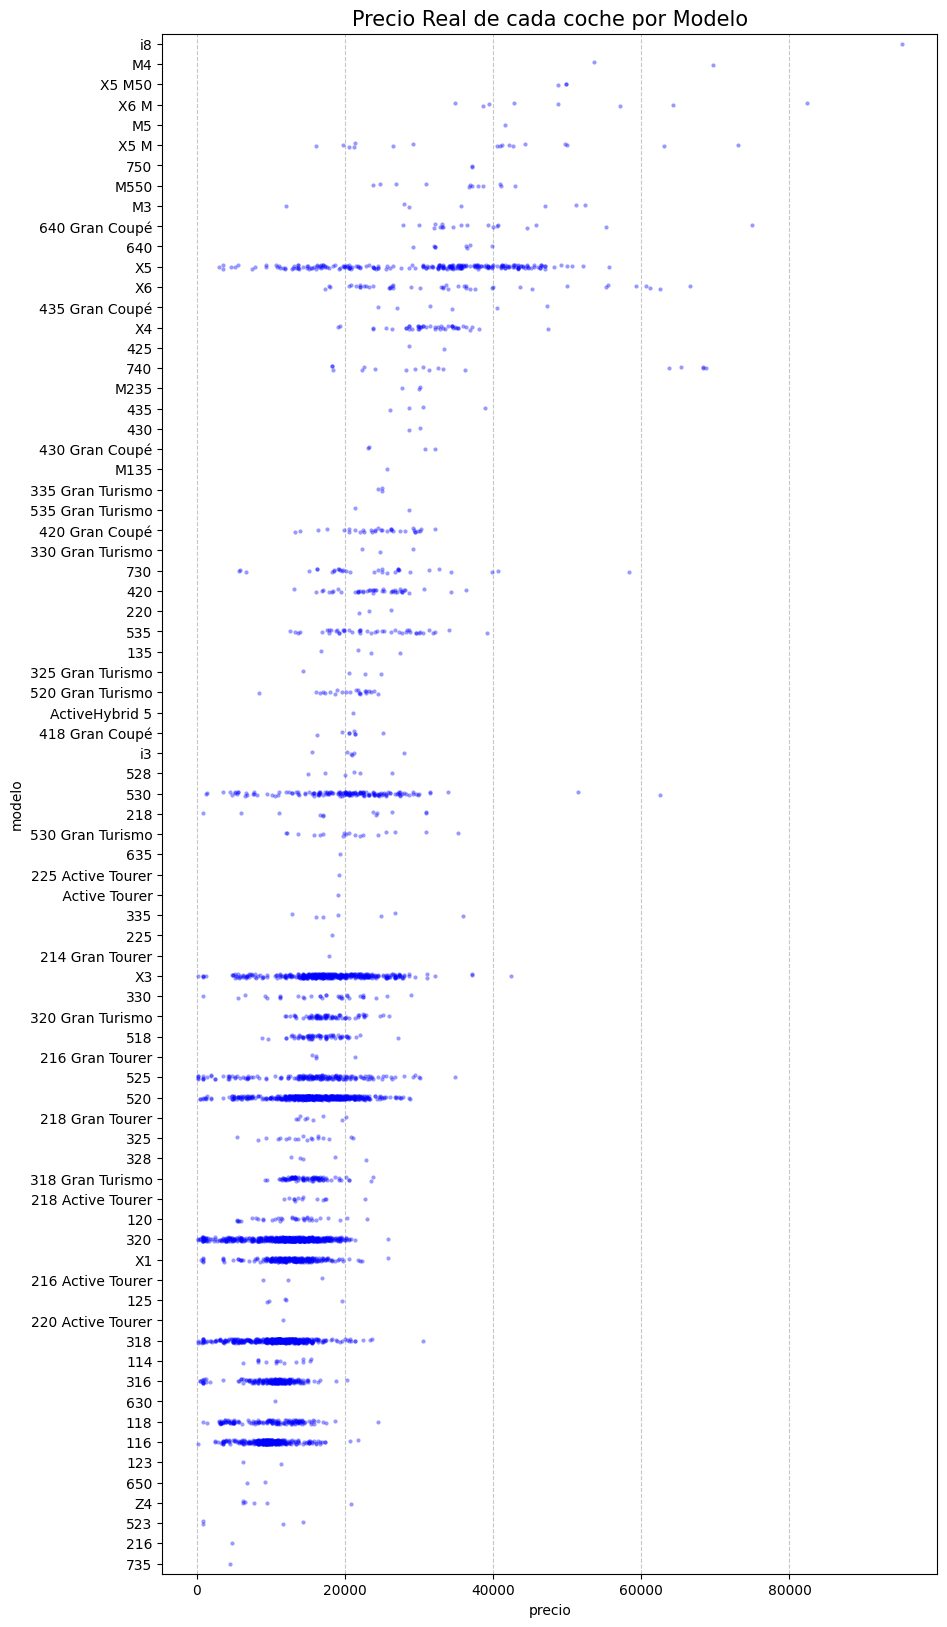

In [67]:
plt.figure(figsize=(10, 20))

# Usamos el mismo orden de precio
orden_precio = df_analisis.groupby('modelo')['precio'].median().sort_values(ascending=False).index

sns.stripplot(x='precio', y='modelo', data=df_analisis,
              order=orden_precio, color='blue',
              size=3, alpha=0.4, jitter=True)

plt.title('Precio Real de cada coche por Modelo', fontsize=15)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

In [ ]:
# Podemos llegar a la conclusión que un BMW será más caro contra más potencia tenga, contra menos kilometraje tenga, y
# contra más extras tenga, a excepción del GPS.

---

# **6. Transformación de categóricas a numéricas, ¿Qué variables van a transformar? ¿Que técnica se va usar?**



In [68]:
df_encoded = df_analisis.copy()

categories_ohe = ['tipo_coche', 'tipo_gasolina', 'color', 'modelo']
ohe_feature_names = []

for col in categories_ohe:
    df_encoded[col] = df_encoded[col].astype(str)
    ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore', dtype=bool)
    encoded_cols = ohe.fit_transform(df_encoded[[col]])
    current_col_names = [f"{col}_{cat}" for cat in ohe.categories_[0]]
    ohe_feature_names.extend(current_col_names)
    encoded_df = pd.DataFrame(encoded_cols, columns=[f"{col}_{cat}" for cat in ohe.categories_[0]], index=df_encoded.index)
    df_encoded = pd.concat([df_encoded, encoded_df], axis=1)
    df_encoded_2 = df_encoded.drop(columns=[col]).copy()

df_encoded_2.shape

(4831, 113)

In [153]:
ohe_feature_names

['tipo_coche_convertible',
 'tipo_coche_coupe',
 'tipo_coche_estate',
 'tipo_coche_hatchback',
 'tipo_coche_sedan',
 'tipo_coche_subcompact',
 'tipo_coche_suv',
 'tipo_coche_van',
 'tipo_gasolina_diesel',
 'tipo_gasolina_electro',
 'tipo_gasolina_hybrid_petrol',
 'tipo_gasolina_petrol',
 'color_beige',
 'color_black',
 'color_blue',
 'color_brown',
 'color_desconocido',
 'color_green',
 'color_grey',
 'color_orange',
 'color_red',
 'color_silver',
 'color_white',
 'modelo_114',
 'modelo_116',
 'modelo_118',
 'modelo_120',
 'modelo_123',
 'modelo_125',
 'modelo_135',
 'modelo_214 Gran Tourer',
 'modelo_216',
 'modelo_216 Active Tourer',
 'modelo_216 Gran Tourer',
 'modelo_218',
 'modelo_218 Active Tourer',
 'modelo_218 Gran Tourer',
 'modelo_220',
 'modelo_220 Active Tourer',
 'modelo_225',
 'modelo_225 Active Tourer',
 'modelo_316',
 'modelo_318',
 'modelo_318 Gran Turismo',
 'modelo_320',
 'modelo_320 Gran Turismo',
 'modelo_325',
 'modelo_325 Gran Turismo',
 'modelo_328',
 'modelo_33

In [69]:
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestRegressor

def evaluar_modelo(X, y):
    """Función auxiliar para entrenar y evaluar rápidamente con Validación Cruzada"""
    model = RandomForestRegressor(n_estimators=50, random_state=42, n_jobs=-1)
    # Usamos cross_val_score para ser más honestos con el resultado (R2 score negativo = mal modelo)
    scores = cross_val_score(model, X, y, cv=3, scoring='r2')
    return scores.mean()

y = df_encoded_2['precio']
X = df_encoded_2[ohe_feature_names + ['km', 'potencia', 'antigüedad']]

resultado_r2 = evaluar_modelo(X, y)
print(f"R2 promedio del modelo: {resultado_r2:.4f}")

R2 promedio del modelo: 0.6580


---

# **7. Escalar variables (usando minmaxscaler) y luego aplicar la correlación final de variables ¿Hay alguna variable finalmente correlacionada?**


In [70]:
df_scaled = df_encoded_2.copy()

scaler = MinMaxScaler()
df_scaled[nums] = scaler.fit_transform(df_scaled[nums])
df_scaled[nums].describe()

,km,potencia,antigüedad
count,4831.000000,4831.000000,4831.000000
mean,0.140485,0.304958,0.173082
std,0.060131,0.092249,0.080656
min,0.000000,0.000000,0.000000
25%,0.102448,0.236407,0.133227
50%,0.140601,0.283688,0.157423
75%,0.174737,0.319149,0.184507
max,1.000000,1.000000,1.000000


In [156]:
df_scaled.columns.shape

(112,)

In [ ]:
corr_final = df_scaled.corr(numeric_only=True)

plt.figure(figsize=(500, 400))

sns.heatmap(corr_final,
            annot=True,        # Escribe el número dentro del cuadro
            fmt=".2f",         # Solo 2 decimales para que ocupe menos
            cmap='RdBu_r',     # Red-Blue reverse (Rojo=Positivo, Azul=Negativo)
            center=0,          # IMPORTANTE: Esto fuerza al 0 a ser blanco
            vmin=-1, vmax=1,   # Límites para que los colores sean simétricos
            square=True,       # Cuadraditos perfectos
            linewidths=.5)     # Líneas blancas entre celdas para limpieza

plt.title('Matriz de Correlación', fontsize=10)
plt.show()

KeyboardInterrupt: 

In [ ]:
# 1. Configuración
target = 'precio'
umbral = 0.1  # Tu parámetro: Mínima correlación para aparecer en el mapa
# 2. Calcular la correlación de TODAS las variables contra el PRECIO
# Usamos abs() porque nos interesa la magnitud, no el signo (-0.8 es muy importante)
corrs_con_target = df_scaled.corr(numeric_only=True)[target]
features_importantes = corrs_con_target[abs(corrs_con_target) > umbral].index
# 3. Crear una nueva matriz de correlación SOLO con esas columnas seleccionadas
corr_final_filtrada = df_scaled[features_importantes].corr(numeric_only=True)
# 4. Graficar
# Ajustamos el tamaño dinámicamente según cuántas variables hayan sobrevivido
n_vars = len(features_importantes)
plt.figure(figsize=(n_vars * 0.8, n_vars * 0.7)) # Tamaño automático razonable
sns.heatmap(corr_final_filtrada,
            annot=True,
            fmt=".2f",
            cmap='RdBu_r',
            center=0,
            vmin=-1, vmax=1,
            square=True,
            linewidths=.5,
            cbar_kws={"shrink": .8}) # Hace la barra de color un poco más pequeña
plt.title(f'Variables con correlación > {umbral} con {target}', fontsize=12)
plt.show()

In [ ]:
# 1. Configuración
target = 'precio'
umbral = 0.2

# 2. Calcular la correlación de TODAS las variables contra el PRECIO
corrs_con_target = df_scaled.corr(numeric_only=True)[target]

# --- MODIFICACIÓN: EXCLUIR PRIMERAS 14 COLUMNAS ---
# Identificamos los nombres de las columnas 0 a 13
columnas_a_ignorar = df_scaled.columns[:14]

# Filtramos: Nos quedamos con la correlación SOLO si:
# A) La columna NO está en la lista de ignoradas  O
# B) La columna es el propio 'target' (para que salga en la gráfica)
corrs_con_target = corrs_con_target[
    (~corrs_con_target.index.isin(columnas_a_ignorar)) |
    (corrs_con_target.index == target)
]
# --------------------------------------------------

# Aplicamos el filtro del umbral (Features importantes)
features_importantes = corrs_con_target[abs(corrs_con_target) > umbral].index

# 3. Crear una nueva matriz de correlación SOLO con esas columnas seleccionadas
corr_final_filtrada = df_scaled[features_importantes].corr(numeric_only=True)

# 4. Graficar
n_vars = len(features_importantes)

# Si tras filtrar quedan muy pocas variables, aseguramos un tamaño mínimo de gráfica
figsize_w = max(6, n_vars * 0.8)
figsize_h = max(5, n_vars * 0.7)
plt.figure(figsize=(figsize_w, figsize_h))

sns.heatmap(corr_final_filtrada,
            annot=True,
            fmt=".2f",
            cmap='RdBu_r',
            center=0,
            vmin=-1, vmax=1,
            square=True,
            linewidths=.5,
            cbar_kws={"shrink": .8})

plt.title(f'Variables (excluyendo primeras 14) con correlación > {umbral}', fontsize=12)
plt.show()

---

In [1]:
df_scaled.info(True)

NameError: name 'df_scaled' is not defined

In [ ]:
df_excel = df_test.head(50).copy()

In [ ]:
df_excel.to_excel("bmw.xlsx", index=False)

---